<a href="https://colab.research.google.com/github/RenzoEspinozaTuesta/Miner-a-de-Datos/blob/main/Proyecto_Integrador_CRISP_DM_PYMA_INDIANS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Elaborado por: Renzo Espinoza Tuesta

# Proyecto Integrador

---

# Fase 1: Business Understanding (Entendimiento del Negocio)

##**1.1. Contexto del dataset y el problema a resolver**

El presente laboratorio está basado en el conjunto de datos clásico sobre mujeres Pima Indians, utilizado para estudios de predicción de diabetes. Este dataset contiene información clínica y biológica de pacientes con el objetivo de predecir si desarrollarán diabetes. Para ello, se emplea la metodología CRISP-DM que permite estructurar el proceso de análisis desde la comprensión del negocio hasta la modelación.

En este laboratorio trabajaremos **hasta la preparación final de los datos**, antes de modelar. Los datos provienen de un estudio epidemiológico realizado por el Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales de Estados Unidos, enfocándose en mujeres de al menos 21 años de edad de herencia indígena Pima que viven cerca de Phoenix, Arizona.

Entonces, aplicaremos la metodología CRISP-DM hasta la etapa de elaboración del modelo predictivo en un contexto médico real, desarrollando habilidades de análisis exploratorio de datos (EDA) en el ámbito de la salud.


## 1.2. Definir objetivos de negocio (¿Qué problema se quiere resolver?)



**1.2. Preguntas de negocio o investigación**

1.- ¿Qué variables de las 8 independientes son las que tienen un mayor grado de de significancia para el modelo?

2.- ¿Qué variables de las 8 independientes tienen una relación estadísticamente más fuerte o relevante con la variable objetivo?

3.- ¿Qué variables contribuyen de forma más significativa a predecir si una persona tiene o no diabetes?

4.- ¿Cuáles variables realmente importan en el modelo?

5.- ¿Cuáles variables, si las quitamos, afectarían más al rendimiento del modelo?

6.- ¿Cuáles tienen mayor poder predictivo o influencia estadística sobre el resultado?

## 1.3. Formular objetivos analíticos (¿Qué necesitamos predecir/clasificar?)

**Define la variable dependiente (Y) y las principales variables independientes (X).**

Variables independientes:
  1. Pregnancies: Número de embarazos
  2. Glucose: Concentración de glucosa en plasma (mg/dL)
  3. BloodPressure: Presión arterial diastólica (mm Hg)
  4. SkinThickness: Grosor del pliegue cutáneo del tríceps (mm)
  5. Insulin: Insulina sérica de 2 horas (mu U/ml)
  6. BMI: Índice de masa corporal (peso kg/(altura m)²)
  7. DiabetesPedigreeFunction: Función de pedigrí de diabetes
  8. Age: Edad (años)


Variables dependiente:

  9. Outcome: Variable objetivo (0 = No diabetes, 1 = Diabetes.)

## 1.4. Establecer criterios de éxito (KPIs medibles)

## 1.5. Traducir el problema empresarial en preguntas de investigación

# Fase 2: Data Understanding (Entendimiento de los Datos)


## 2.1. Adquirir los datos del repositorio UCI

In [ ]:
# ========================
# Configuración inicial
# ========================
# (1) Librerías adicionales (diagnósticos y ordinal)
!pip -q install statsmodels seaborn
!pip -q install fancyimpute       # Libreria para la imputacion de datos por el metodo MICE.

# (2) Imports principales
import numpy as np # Cálculo numérico
import pandas as pd # DataFrames
import matplotlib.pyplot as plt # Visualización base
import seaborn as sns # Visualización avanzada
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler # Escalado
from sklearn.linear_model import LogisticRegression # Regresión logística
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                           roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
                           classification_report, log_loss) # Métricas
import statsmodels.api as sm # Diagnósticos (logit, residuos)
from statsmodels.stats.outliers_influence import variance_inflation_factor # VIF
from statsmodels.stats.diagnostic import het_breuschpagan, het_white # Tests de heterocedasticidad
from statsmodels.stats.stattools import durbin_watson # Test Durbin-Watson
from scipy import stats
import warnings; warnings.filterwarnings('ignore') # Salida limpia

from fancyimpute import IterativeImputer

# (3) Semilla para reproducibilidad
np.random.seed(42)

# (4) Estilo de gráficos mejorado
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")
sns.set_palette("husl")

print("🎯 LABORATORIO COMPLETO: REGRESIÓN LOGÍSTICA - DIABETES (PIMA INDIANS)")
print("=" * 80)

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 7.0 MB/s eta 0:00:00
🎯 LABORATORIO COMPLETO: REGRESIÓN LOGÍSTICA - DIABETES (PIMA INDIANS)


In [ ]:
# =========================================
# 1. CARGA Y EXPLORACIÓN INICIAL DE DATOS
# =========================================
print("\n📊 FASE 1: CARGA Y EXPLORACIÓN INICIAL DE DATOS")
print("-" * 50)

# Cargar dataset desde URL (Pima Indians Diabetes Database)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Carga de datos
diabetes_df = pd.read_csv(url, header=None, names=column_names)

print("✅ Dataset cargado exitosamente desde:", url)


📊 FASE 1: CARGA Y EXPLORACIÓN INICIAL DE DATOS
--------------------------------------------------
✅ Dataset cargado exitosamente desde: https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv


## 2.2. Describir el dataset (dimensiones, variables, tipos de datos)

In [ ]:
# ========================
# Información básica del dataset
# ========================
print("\n📋 INFORMACIÓN BÁSICA DEL DATASET:")
print(f"• Observaciones: {diabetes_df.shape[0]}")
print(f"• Variables predictoras: {diabetes_df.shape[1]-1}")
print(f"• Forma del dataset: {diabetes_df.shape}")



📋 INFORMACIÓN BÁSICA DEL DATASET:
• Observaciones: 768
• Variables predictoras: 8
• Forma del dataset: (768, 9)


Dataset incluye las siguientes variables:
  1. Pregnancies: Número de embarazos
  2. Glucose: Concentración de glucosa en plasma (mg/dL)

      Unidad: mg/dL (miligramos por decilitro)

      Explicación: Mide la concentración de glucosa en el plasma sanguíneo. Es la unidad estándar en países como Estados Unidos. Un valor en ayunas superior a 126 mg/dL es un criterio de diagnóstico para diabetes.

  3. BloodPressure: Presión arterial diastólica (mm Hg)
      Unidad: mm Hg (milímetros de mercurio)

      Explicación: Esta variable se refiere específicamente a la presión arterial diastólica, que es la presión en las arterias cuando el corazón descansa entre latidos. Un valor normal está por debajo de 80 mm Hg. Valores consistentemente altos (≥ 90 mm Hg) indican hipertensión.

  4. SkinThickness: Grosor del pliegue cutáneo del tríceps (mm)

      Unidad: mm (milímetros)

      Explicación: Mide el grosor de un pliegue de piel, generalmente en el tríceps. Se utiliza para estimar la grasa corporal subcutánea. Un grosor elevado puede indicar un mayor porcentaje de grasa corporal.

  5. Insulin: Insulina sérica de 2 horas (mu U/ml)

      Unidad: mu U/ml (o µU/mL, micro-unidades internacionales por mililitro)

      Explicación: Mide la concentración de insulina en el suero sanguíneo 2 horas después de ingerir una solución de glucosa (como parte de una prueba de tolerancia oral a la glucosa). Ayuda a evaluar cómo responde el páncreas. Un valor alto puede indicar resistencia a la insulina.

  6. BMI: Índice de masa corporal (peso kg/(altura m)²)

      Unidad: kg/m² (kilogramos por metro cuadrado)

      Explicación: Es una medida que relaciona el peso y la talla para categorizar el estado ponderal.

      Bajo peso: < 18.5

      Normal: 18.5 – 24.9

      Sobrepeso: 25 – 29.9

      Obesidad: ≥ 30

  7. DiabetesPedigreeFunction: Función de pedigrí de diabetes

  8. Age: Edad (años)

  9. Outcome: Variable objetivo (0 = No diabetes, 1 = Diabetes.)

## 2.3. Realizar Análisis Exploratorio de Datos (EDA):

In [ ]:
# Mostrar primeras filas
print("\n🔍 PRIMERAS 15 OBSERVACIONES:")
print(diabetes_df.head(15))

# Información de tipos de datos
print("\n📊 INFORMACIÓN DE TIPOS DE DATOS:")
print(diabetes_df.info())


🔍 PRIMERAS 15 OBSERVACIONES:
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0             6      148             72             35        0  33.6   
1             1       85             66             29        0  26.6   
2             8      183             64              0        0  23.3   
3             1       89             66             23       94  28.1   
4             0      137             40             35      168  43.1   
5             5      116             74              0        0  25.6   
6             3       78             50             32       88  31.0   
7            10      115              0              0        0  35.3   
8             2      197             70             45      543  30.5   
9             8      125             96              0        0   0.0   
10            4      110             92              0        0  37.6   
11           10      168             74              0        0  38.0   
12           10      

### 2.3.1. **Estadísticas descriptivas univariadas**

In [ ]:
# =========================================
# 🔍 2.3.1. Estadísticas descriptivas
# =========================================

print("\n FASE 2: ESTADÍSTICAS DESCRIPTIVAS")
print("-" * 60)

# 2.1 Estadísticas descriptivas
print("\n📊 ESTADÍSTICAS DESCRIPTIVAS:")
print(diabetes_df.describe().round(2))



 FASE 2: ESTADÍSTICAS DESCRIPTIVAS
------------------------------------------------------------

📊 ESTADÍSTICAS DESCRIPTIVAS:
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   120.89          69.11          20.54    79.80   31.99   
std           3.37    31.97          19.36          15.95   115.24    7.88   
min           0.00     0.00           0.00           0.00     0.00    0.00   
25%           1.00    99.00          62.00           0.00     0.00   27.30   
50%           3.00   117.00          72.00          23.00    30.50   32.00   
75%           6.00   140.25          80.00          32.00   127.25   36.60   
max          17.00   199.00         122.00          99.00   846.00   67.10   

       DiabetesPedigreeFunction     Age  Outcome  
count                    768.00  768.00   768.00  
mean                       0.47   33.24     0.35  
std              

diabetes_df.describe() genera un cuadro resumen con las estadísticas más comunes para cada columna numérica:

      count: cuántos datos válidos hay (sin NaN).

      mean: promedio.

      std: desviación estándar (dispersión).

      min: valor mínimo.

      25%: percentil 25 (cuartil 1).

      50%: percentil 50 (mediana).

      75%: percentil 75 (cuartil 3).

      max: valor máximo.

      .round(2) redondea todos los números a 2 decimales.

### 2.3.2. Análisis de distribuciones

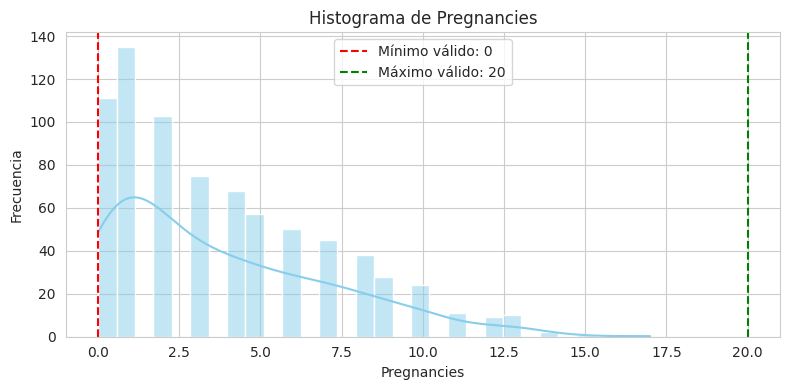

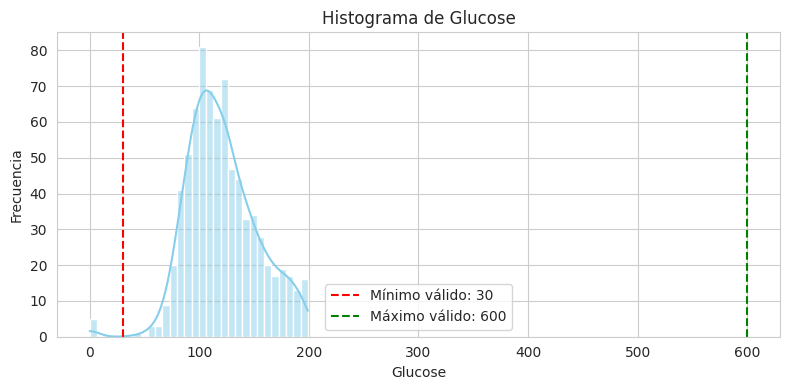

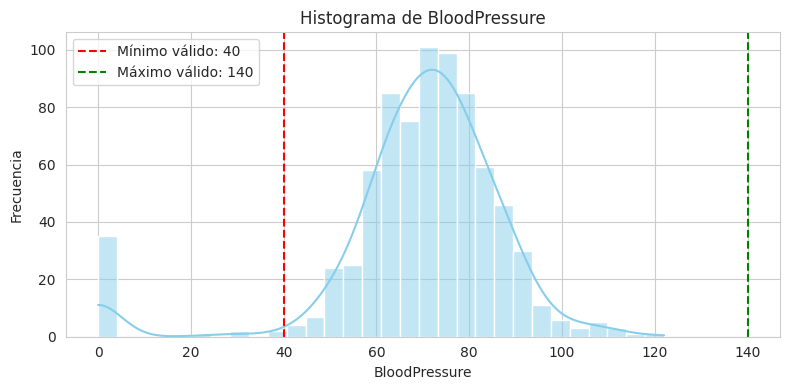

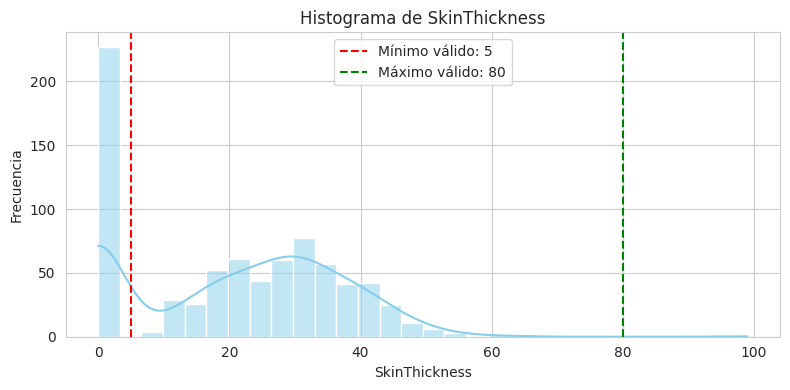

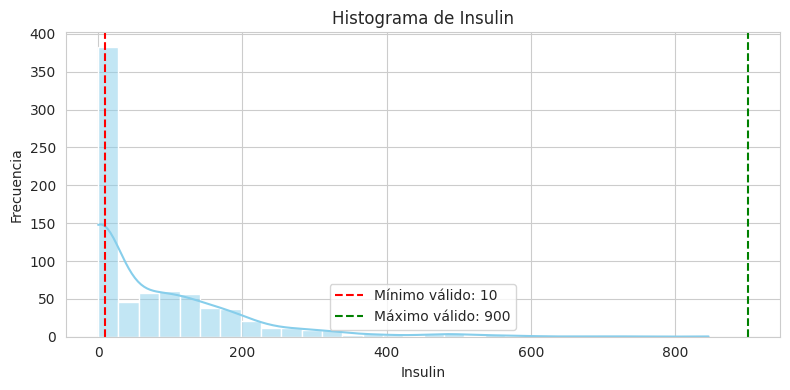

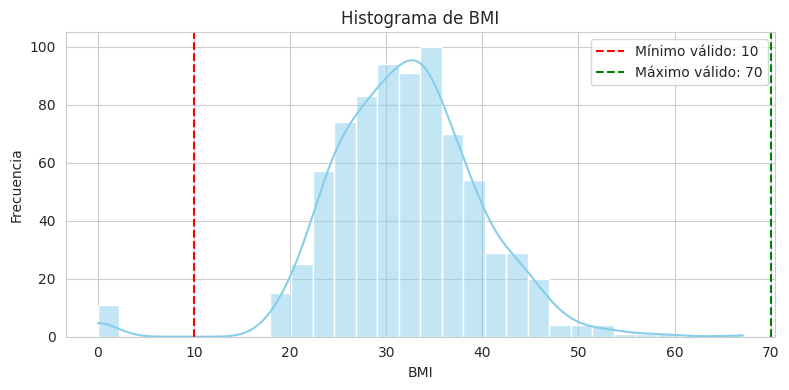

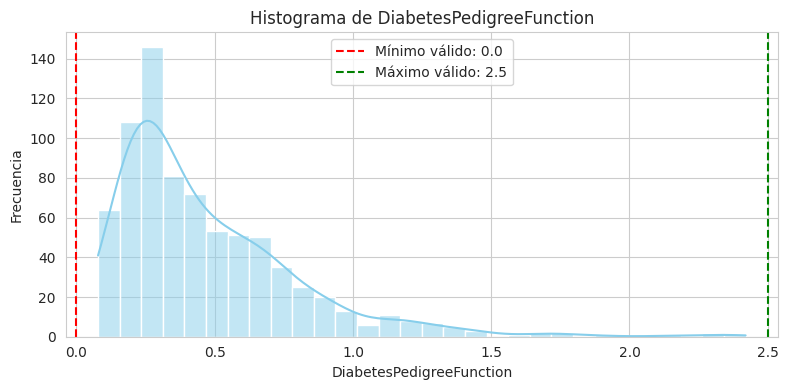

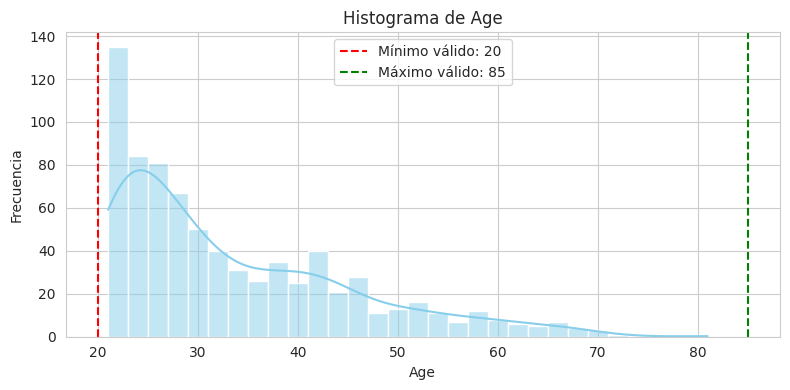

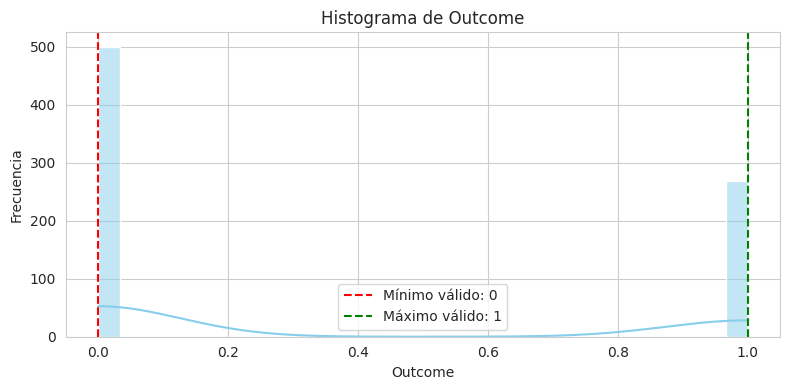

In [ ]:
# ========================
# Datos inconsistentes
# ========================

rangos_validos = {
    'Pregnancies': (0, 20),
    'Glucose': (30, 600),
    'BloodPressure': (40, 140),
    'SkinThickness': (5, 80),
    'Insulin': (10, 900),
    'BMI': (10, 70),
    'DiabetesPedigreeFunction': (0.0, 2.5),
    'Age': (20, 85),
    'Outcome': (0, 1)  # Solo 0 o 1
}


### rangos_validos:
### Es un diccionario donde cada clave es el nombre de una columna y el valor es una tupla con el rango válido.
### El código que muestras sirve para limpiar datos fuera de un rango válido en el DataFrame diabetes_df.


# Graficar cada variable
for col, (min_val, max_val) in rangos_validos.items():
    plt.figure(figsize=(8, 4))
    sns.histplot(diabetes_df[col], bins=30, kde=True, color='skyblue')
    plt.axvline(min_val, color='red', linestyle='--', label=f'Mínimo válido: {min_val}')
    plt.axvline(max_val, color='green', linestyle='--', label=f'Máximo válido: {max_val}')
    plt.title(f'Histograma de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.tight_layout()
    plt.show()

### Glucosa Valores biológicos de Glucosa en Sangre:

  1. Glucosa
    Valores biológicos de Glucosa en Sangre:

    1.1. Prueba Aleatoria (sin ayuno):

    1.1.1. Normal
    Glucosa (mg/dl) < 200
    Glucosa (mmol/l) < 11.1

    1.1.2. Prediabetes
    Glucosa (mg/dl) = N/A
    Glucosa (mmol/l) = N/A

    1.1.3. Diabetes
    Glucosa (mg/dl) ≥ 200
    Glucosa (mmol/l) ≥ 11.1

    1.2. Prueba en Ayunas (mínimo 8 horas sin comer):

    1.1.1. Normal
    Glucosa (mg/dl) < 108
    Glucosa (mmol/l) < 6.0

    1.1.2. Prediabetes
    Glucosa (mg/dl) = 108 – 125
    Glucosa (mmol/l) = 6.1 – 6.9

    1.1.3. Diabetes
    Glucosa (mg/dl) ≥ 126
    Glucosa (mmol/l) ≥ 7.0

    1.3. Prueba 2 Horas Después de Comer (postprandial):

    1.1.1. Normal
    Glucosa (mg/dl) < 140
    Glucosa (mmol/l) < 7.8

    1.1.2. Prediabetes
    Glucosa (mg/dl) = 140 – 199
    Glucosa (mmol/l) = 7.8 – 11.0

    1.1.3. Diabetes
    Glucosa (mg/dl) ≥ 200
    Glucosa (mmol/l) ≥ 11.1

    FUENTE:
    Tablas de los rangos de los niveles de azúcar en la sangre
    https://www.diabetes.ac/rangos-los-niveles-azucar-en-la-sangre/


---


    2. Insulina
    Valores biológicos de Insulina en Sangre:

    a) Estado Normal:

    < 140 mg/dL (7.8 mmol/L)

    Entre 30 y 100 µUI/mL.
    El páncreas responde de forma adecuada a la carga de azúcar, liberando una cantidad suficiente de insulina para normalizar la glucosa.

    b) Prediabetes:

    140 - 199 mg/dL (7.8 - 11.0 mmol/L)

    A menudo por encima de 100-150 µUI/mL, o desproporcionadamente alta.
    Esto indica RESISTENCIA A LA INSULINA. El cuerpo necesita producir mucha más insulina de lo normal para intentar mantener la glucosa bajo control. El páncreas trabaja forzadamente.

    c) Diabetes Tipo 1:

    ≥ 200 mg/dL (11.1 mmol/L)

    Variable, pero típicamente ALTA al principio y BAJA en etapas avanzadas.
    • Inicio: La insulina puede estar muy elevada (ej. >150 µUI/mL), pero es ineficaz debido a la fuerte resistencia.
    • Avanzada: El páncreas se agota y la producción de insulina cae (ej. < 30-50 µUI/mL), por lo que la glucosa se dispara.

    d) Diabetes Tipo 2:

    ≥ 200 mg/dL (11.1 mmol/L)

    Muy Baja o Indetectable.
    Generalmente < 5-10 µUI/mL.
    El sistema inmunitario ha destruido las células que producen insulina, por lo que el páncreas no puede responder a la glucosa en absoluto.

    FUENTE:
    ADA Standards of Care - Sección 2: Diagnosis and Classification of Diabetes
    https://diabetesjournals.org/care/issue/47/Supplement_1

Las siguientes variables presentan registros con valor igual a cero que, desde una perspectiva clínica, carecen de sentido fisiológico. A continuación se enumeran junto con sus rangos de referencia y una breve justificación:

      * Glucose (Concentración de glucosa en plasma) Rango fisiológico válido: 40–600 mg/dL Un valor de 0 mg/dL es incompatible con la vida humana, ya que indicaría ausencia total de glucosa en sangre. Clínicamente, incluso en estados hipoglucémicos severos, los valores no descienden a cero. Este valor suele representar un dato faltante mal codificado.

      * BloodPressure (Presión arterial diastólica) Rango fisiológico válido: 40–140 mm Hg Una presión diastólica de 0 mm Hg implicaría un colapso circulatorio, lo cual no es posible en un paciente consciente ni en condiciones normales de medición. En la práctica, este valor refleja ausencia de registro.

      * SkinThickness (Grosor del pliegue cutáneo del tríceps) Rango fisiológico válido: 5–80 mm Un grosor de 0 mm sugiere ausencia de tejido subcutáneo, lo cual no tiene sentido anatómico. Este tipo de medición requiere contacto físico y puede fallar si el operador no realiza la lectura correctamente.

      * Insulin (Insulina sérica de 2 horas) Rango fisiológico válido: 10–900 mu U/ml Un valor de 0 mu U/ml indicaría una supresión total de la secreción de insulina, lo cual es extremadamente raro incluso en pacientes con diabetes tipo 1. En la mayoría de casos, este valor refleja ausencia de medición o error de captura.

      * BMI (Índice de masa corporal) Rango fisiológico válido: 10–70 kg/m² Un IMC de 0 kg/m² implicaría una masa corporal nula, lo cual es anatómicamente imposible. Este valor suele surgir por errores en el cálculo o en la entrada de datos.

      Desde una perspectiva clínica, estos valores son problemáticos porque distorsionan las distribuciones estadísticas, afectan la calidad del modelado y pueden inducir sesgos en algoritmos de aprendizaje automático si no se tratan adecuadamente. Por ello, se recomienda convertirlos en valores nulos (NaN) y aplicar técnicas de imputación apropiadas.

### **Visualizaciones apropiadas**

**1.1. Visualización de datos biológicamente imposibles.**

Tratamiento de valores faltantes (imputación clínica)
En este dataset, los valores cero en ciertas variables son biológicamente imposibles y se interpretan como datos faltantes:

Glucose = 0 → imposible → faltante

BloodPressure = 0 → imposible → faltante

SkinThickness = 0 → muy raro → faltante

Insulin = 0 → posible, pero comúnmente tratado como faltante en análisis

BMI = 0 → imposible → faltante

Por lo tanto, los 0 serán reemplazados por la predicción realizada por la regresión en base a las demás variables.

---
**1.2. Transformación de variables categóricas (codificación dummy, label o ordinal según corresponda).**

NO CORRESPONDE

---
**1.3. Escalamiento o normalización de las variables numéricas si aplica..**

NO CORRESPONDE

---
**1.4. Análisis exploratorio breve (gráficos o resúmenes estadísticos relevantes).**

SÍ CORRESPONDE


### 2.3.3. Identificación de correlaciones bivariadas
MAPA DE CALOR DE CORRELACIONES

In [ ]:
# ========================
# 2.2 Matriz de correlación
# ========================
print("\n ANÁLISIS DE CORRELACIONES:")
correlation_matrix = diabetes_df.corr()
print("Correlaciones entre variables clave (valores > 0.8 indican alta colinealidad):")
print(correlation_matrix.round(3))


 ANÁLISIS DE CORRELACIONES:
Correlaciones entre variables clave (valores > 0.8 indican alta colinealidad):
                          Pregnancies  Glucose  BloodPressure  SkinThickness  \
Pregnancies                     1.000    0.129          0.141         -0.082   
Glucose                         0.129    1.000          0.153          0.057   
BloodPressure                   0.141    0.153          1.000          0.207   
SkinThickness                  -0.082    0.057          0.207          1.000   
Insulin                        -0.074    0.331          0.089          0.437   
BMI                             0.018    0.221          0.282          0.393   
DiabetesPedigreeFunction       -0.034    0.137          0.041          0.184   
Age                             0.544    0.264          0.240         -0.114   
Outcome                         0.222    0.467          0.065          0.075   

                          Insulin    BMI  DiabetesPedigreeFunction    Age  \
Pregnancies   

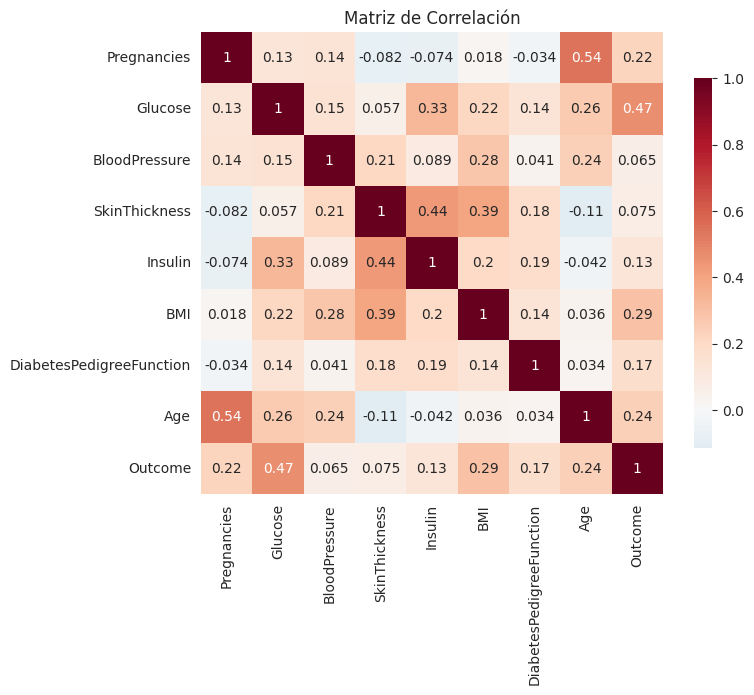

In [ ]:
# Mapa de calor de correlaciones
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0,
            square=True, cbar_kws={"shrink": .8})
plt.title('Matriz de Correlación')
plt.show()

14. ¿Qué variables muestran mayor correlación (positiva o negativa) con la variable objetivo? Enumera las 5 más importantes y explica el sentido médico de estas correlaciones.

La variable que muestra mayor correlación con el Outcome (presencia de diabetes) es:

Glucose, con un coeficiente de 0.49, lo cual tiene pleno sentido médico, ya que niveles elevados de glucosa en sangre son el principal indicador clínico de diabetes.

Le sigue el BMI (Índice de Masa Corporal) con una correlación de 0.31, reflejando que el sobrepeso y la obesidad aumentan la resistencia a la insulina y, por tanto, el riesgo de desarrollar diabetes tipo 2.

En tercer lugar está Age, con una correlación de 0.24, lo que indica que el riesgo de diabetes aumenta con la edad debido al deterioro metabólico progresivo.

Luego aparece Pregnancies con 0.22, lo cual puede estar relacionado con la diabetes gestacional en mujeres con múltiples embarazos.

Finalmente, DiabetesPedigreeFunction muestra una correlación de 0.17, representando la carga genética o antecedentes familiares, que también influyen en la probabilidad de desarrollar la enfermedad.

### 2.3.4 Visualizaciones apropiadas (histogramas, boxplots, heatmaps, pairplots)

### Visualización de datos inconsistentes

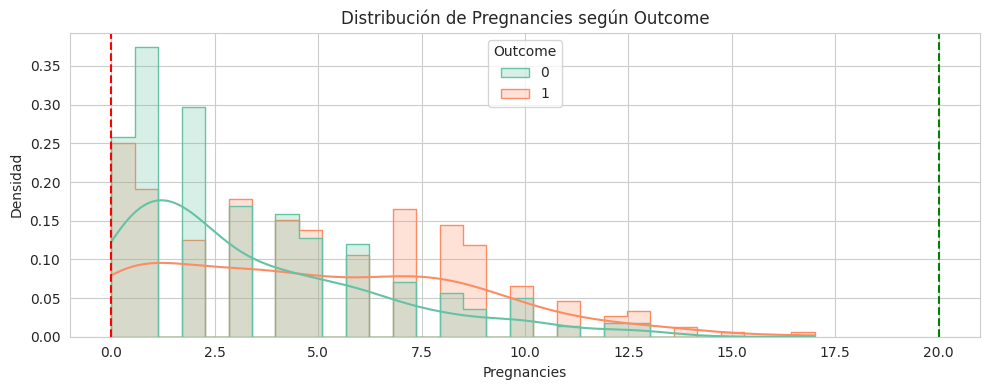

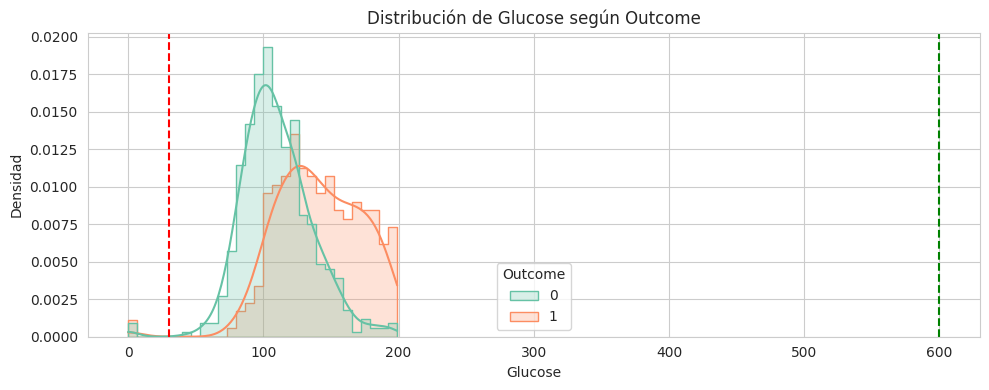

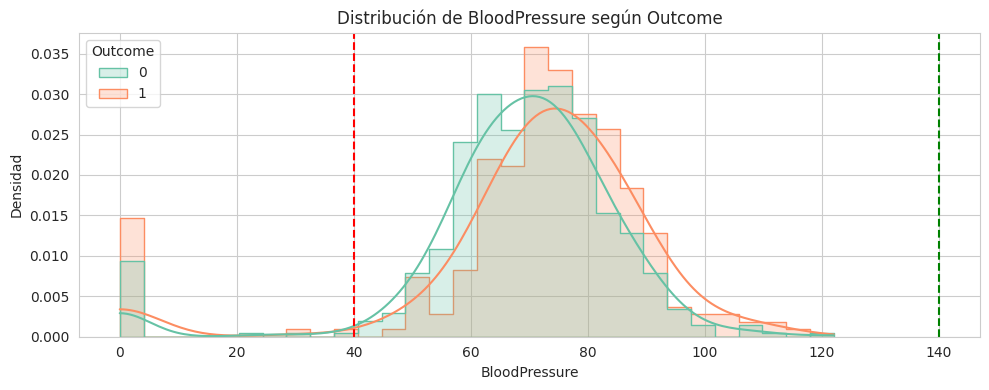

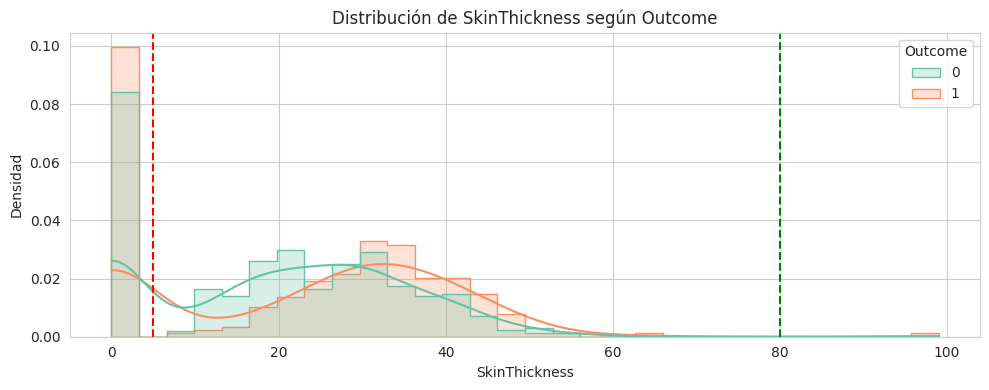

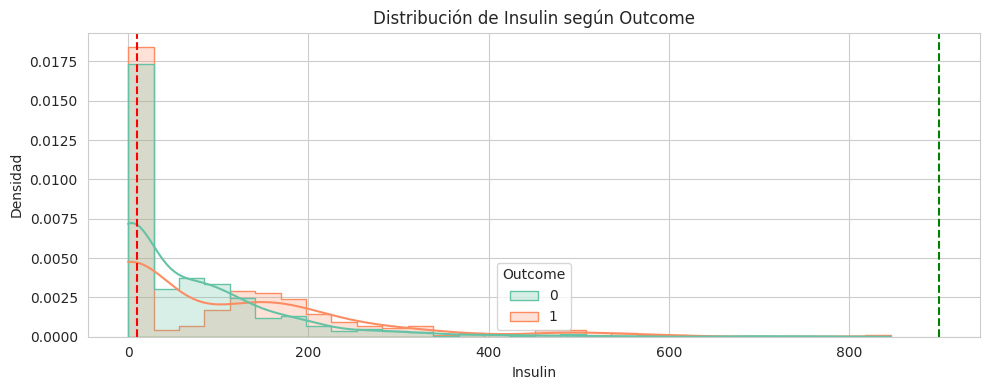

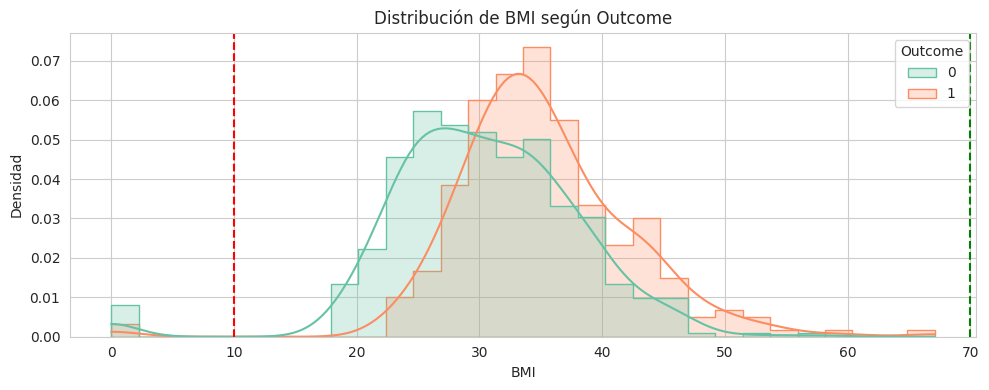

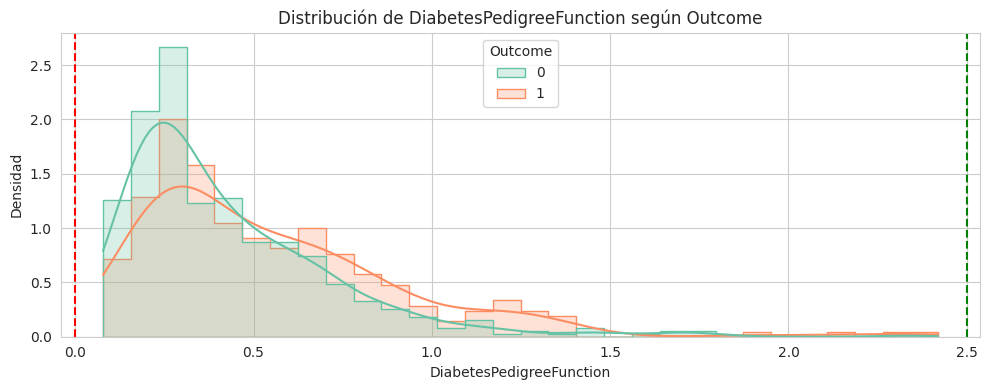

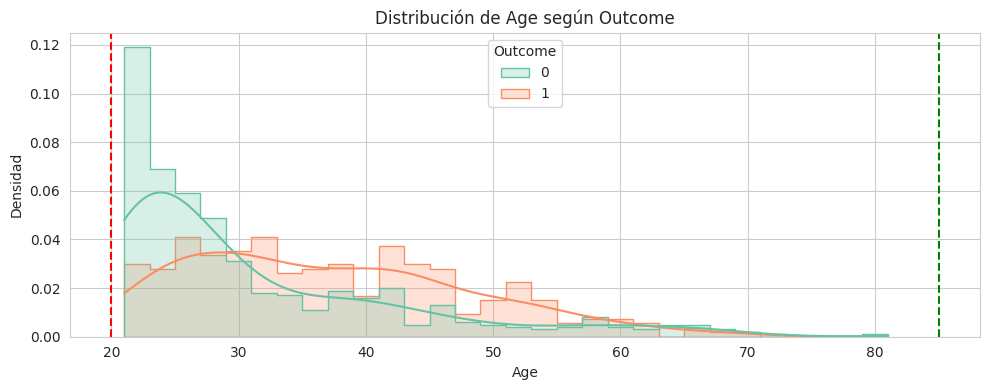

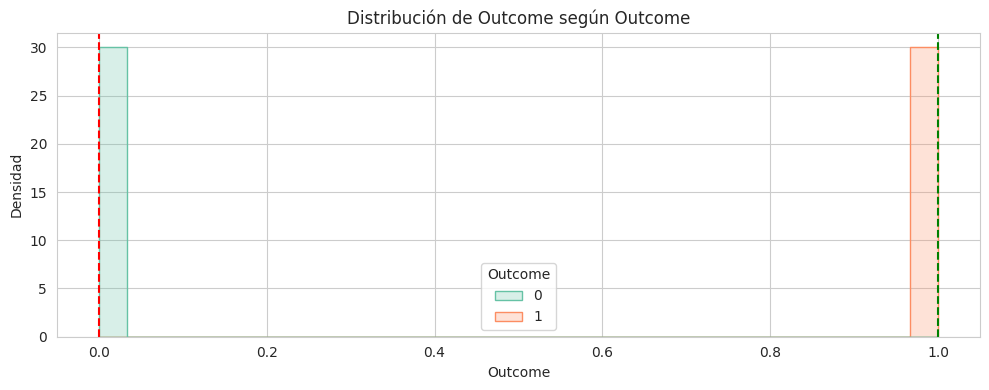

In [ ]:
# ========================
# Datos inconsistentes
# ========================

rangos_validos = {
    'Pregnancies': (0, 20),
    'Glucose': (30, 600),
    'BloodPressure': (40, 140),
    'SkinThickness': (5, 80),
    'Insulin': (10, 900),
    'BMI': (10, 70),
    'DiabetesPedigreeFunction': (0.0, 2.5),
    'Age': (20, 85),
    'Outcome': (0, 1)  # Solo 0 o 1
}


### rangos_validos:
### Es un diccionario donde cada clave es el nombre de una columna y el valor es una tupla con el rango válido.
### El código que muestras sirve para limpiar datos fuera de un rango válido en el DataFrame diabetes_df.


# Seleccionar columnas numéricas excepto Outcome
columnas_numericas = diabetes_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
columnas_numericas = [col for col in columnas_numericas if col != 'Outcome']

# Graficar cada variable con hue='Outcome'
for col, (min_val, max_val) in rangos_validos.items():
    plt.figure(figsize=(10, 4))
    sns.histplot(data=diabetes_df, x=col, hue='Outcome', bins=30, kde=True, palette='Set2', element='step', stat='density', common_norm=False)
    plt.axvline(min_val, color='red', linestyle='--', label=f'Mínimo válido: {min_val}')
    plt.axvline(max_val, color='green', linestyle='--', label=f'Máximo válido: {max_val}')
    plt.title(f'Distribución de {col} según Outcome')
    plt.xlabel(col)
    plt.ylabel('Densidad')
    plt.tight_layout()
    plt.show()

1. Interpretación de Pregnancies según Outcome

  En el grupo de mujeres sin diabetes (Outcome = 0, color verde), la variable Pregnancies muestra una distribución con sesgo positivo. La mayor concentración de casos se encuentra en los valores bajos, entre 0 y 2 embarazos, lo que indica que la mayoría de estas mujeres ha tenido pocos embarazos. Sin embargo, la distribución presenta una cola que se extiende hacia la derecha, alcanzando hasta 15–17 embarazos. Esto sugiere que unas pocas mujeres con muchos embarazos “jalan” la distribución hacia valores altos, generando una asimetría a la derecha.

  En el grupo de mujeres con diabetes (Outcome = 1, color naranja), también se observa una distribución con sesgo positivo, aunque más marcado. Aunque hay concentración en valores bajos-medios, se nota una mayor presencia relativa en el rango de 5 a 10 embarazos. Al igual que en el grupo sin diabetes, la cola de la distribución se extiende hacia valores altos (10–17 embarazos), pero en este caso aparecen más casos en la zona alta, lo que intensifica la asimetría a la derecha.

 2. Interpretación de Glucose según Outcom

  Mujeres sin diabetes (Outcome = 0, verde): La distribución de glucosa en este grupo presenta un sesgo negativo (asimetría a la izquierda). La mayor densidad se concentra alrededor de valores cercanos a 100, pero la cola se extiende hacia la izquierda, hacia niveles más bajos de glucosa. Esto indica que la mayoría de las mujeres sin diabetes tienen niveles moderados de glucosa, mientras que unas pocas presentan valores bajos que “jalan” la distribución hacia la izquierda.

  Mujeres con diabetes (Outcome = 1, rojo): En este grupo, la distribución es más simétrica, con un pico alrededor de 140. Aunque también hay una ligera extensión hacia valores altos, la forma general es más equilibrada. Esto sugiere que los niveles de glucosa en mujeres con diabetes tienden a estar más concentrados en rangos elevados, con menor asimetría que en el grupo sin diabetes.

  3. Interpretación de BloodPressure según Outcom

  Mujeres sin diabetes (Outcome = 0, verde): La distribución de presión arterial en este grupo se aproxima a una forma normal, con un pico alrededor de los 70 mmHg. La curva de densidad es simétrica y no muestra una cola pronunciada hacia ningún extremo, lo que sugiere que el sesgo es prácticamente nulo o muy leve. En otras palabras, los valores de presión arterial están distribuidos de manera bastante equilibrada en torno a la media.

  Mujeres con diabetes (Outcome = 1, naranja): También presenta una distribución cercana a la normal, aunque el pico se desplaza ligeramente hacia la derecha, alrededor de los 80 mmHg. La forma de la curva es simétrica, sin colas marcadas hacia los extremos, lo que indica que el sesgo es mínimo. Sin embargo, el desplazamiento del centro hacia valores más altos sugiere que las mujeres con diabetes tienden a tener una presión arterial ligeramente superior en promedio, aunque sin alterar la simetría de la distribución.

  4. Interpretación de SkinThickness según Outcom
  Mujeres sin diabetes (Outcome = 0, verde): La distribución de SkinThickness en este grupo se concentra en valores bajos, típicamente entre 0 y 30. Aunque hay una ligera extensión hacia valores más altos (hasta 50 o más), la mayoría de los casos se agrupan en el rango bajo. Esto genera una cola hacia la derecha, indicando un sesgo positivo. En términos simples: la mayoría tiene poca grasa subcutánea, pero algunas mujeres presentan valores altos que “jalan” la distribución hacia la derecha.

  Mujeres con diabetes (Outcome = 1, rojo): En este grupo, la distribución también muestra sesgo positivo, pero más marcado. Hay una mayor proporción de mujeres con valores de SkinThickness en el rango medio-alto (30–50), y la cola se extiende hacia valores extremos. Esto sugiere que las mujeres con diabetes tienden a tener mayor grosor de piel en promedio, y que hay más casos con valores elevados que intensifican la asimetría a la derecha.

   5. Interpretación de Insulin según Outcom

  Mujeres sin diabetes (Outcome = 0, verde): La distribución de niveles de insulina en este grupo presenta un sesgo positivo claro. La mayoría de los valores se concentran en rangos bajos, y la curva de densidad muestra una cola larga hacia la derecha, extendiéndose hacia niveles altos de insulina. Esto indica que la mayoría de las mujeres sin diabetes tienen niveles bajos de insulina, pero unas pocas presentan valores muy elevados que “jalan” la distribución hacia la derecha.

  Mujeres con diabetes (Outcome = 1, rojo): También se observa un sesgo positivo, aunque más pronunciado. La densidad se concentra en valores medios-altos, y la cola se extiende aún más hacia niveles extremos de insulina. Esto sugiere que las mujeres con diabetes tienden a tener niveles más elevados de insulina en promedio, y hay una mayor proporción de casos con valores extremos que intensifican la asimetría a la derecha.

   6. Interpretación de BMI (Body Mass Index) según Outcom

  Mujeres sin diabetes (Outcome = 0, verde): La distribución de BMI en este grupo tiende a concentrarse en valores medios, alrededor de 25–30. Aunque la forma general es relativamente simétrica, se observa una ligera cola hacia la derecha, lo que indica un sesgo positivo leve. Esto sugiere que la mayoría de las mujeres sin diabetes tienen un índice de masa corporal dentro del rango saludable o ligeramente elevado, pero hay algunos casos con valores altos que “jalan” la distribución hacia la derecha.

  Mujeres con diabetes (Outcome = 1, rojo): En este grupo, la distribución muestra un sesgo positivo más marcado. La densidad se concentra en valores más altos, típicamente entre 30 y 40, y la cola se extiende hacia valores extremos de BMI. Esto indica que las mujeres con diabetes tienden a tener un índice de masa corporal más elevado en promedio, y hay una mayor proporción de casos con obesidad que intensifican la asimetría a la derecha.

   7. Interpretación de DiabetesPedigreeFunction según Outcom

  Mujeres sin diabetes (Outcome = 0, verde): La distribución de esta variable muestra un sesgo positivo claro. La mayoría de los valores se concentran en rangos bajos, típicamente entre 0.1 y 0.4, pero la cola de la distribución se extiende hacia la derecha, alcanzando valores más altos. Esto indica que la mayoría de las mujeres sin diabetes tienen antecedentes familiares bajos de diabetes, aunque hay algunos casos con valores elevados que “jalan” la distribución hacia la derecha.

  Mujeres con diabetes (Outcome = 1, naranja): También presenta un sesgo positivo, pero más pronunciado. La densidad se concentra en valores medios-altos, y la cola se extiende aún más hacia valores extremos. Esto sugiere que las mujeres con diabetes tienden a tener un mayor índice de carga hereditaria, y hay más casos con valores altos que intensifican la asimetría a la derecha.

  8. Interpretación de Age según Outcom

  Mujeres sin diabetes (Outcome = 0, verde): La distribución de edad en este grupo muestra un sesgo negativo (asimetría a la izquierda). La mayor densidad se concentra en edades jóvenes, especialmente alrededor de los 20 años, y la cola se extiende hacia edades mayores. Esto indica que la mayoría de las mujeres sin diabetes son jóvenes, pero hay algunas de mayor edad que “jalan” la distribución hacia la izquierda.

  Mujeres con diabetes (Outcome = 1, naranja): En este grupo, la distribución es más dispersa y menos pronunciada. Aunque también presenta una ligera asimetría, la densidad se concentra en edades medias, entre los 30 y 50 años, y la cola se extiende hacia edades más avanzadas. El sesgo positivo es leve, pero sugiere que hay más mujeres mayores en este grupo en comparación con el grupo sin diabetes.

### Visualización en cantidades de valores nulos

In [ ]:
# Aplicamos el filtro
for col, (min_val, max_val) in rangos_validos.items():
    diabetes_df[col] = diabetes_df[col].apply(lambda x: x if min_val <= x <= max_val else np.nan)

print(diabetes_df.isna().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                39
SkinThickness               228
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


Recorrido de columnas (for col, (min_val, max_val) in rangos_validos.items()):
Va columna por columna y extrae los valores mínimo y máximo permitidos.

apply(lambda x: ...):

Si el valor x está dentro del rango (min_val <= x <= max_val) → lo conserva.

Si está fuera del rango → lo reemplaza por np.nan (valor faltante).

print(diabetes_df.isna().sum()):
Cuenta cuántos valores quedaron como NaN en cada columna después del filtrado.

Este código detecta valores atípicos o imposibles en cada columna (según los rangos definidos) y los reemplaza con NaN. Luego muestra cuántos datos se invalidaron.

## 2.4. Detectar problemas de calidad:


## 2.4.1. Valores faltantes (% por variable)

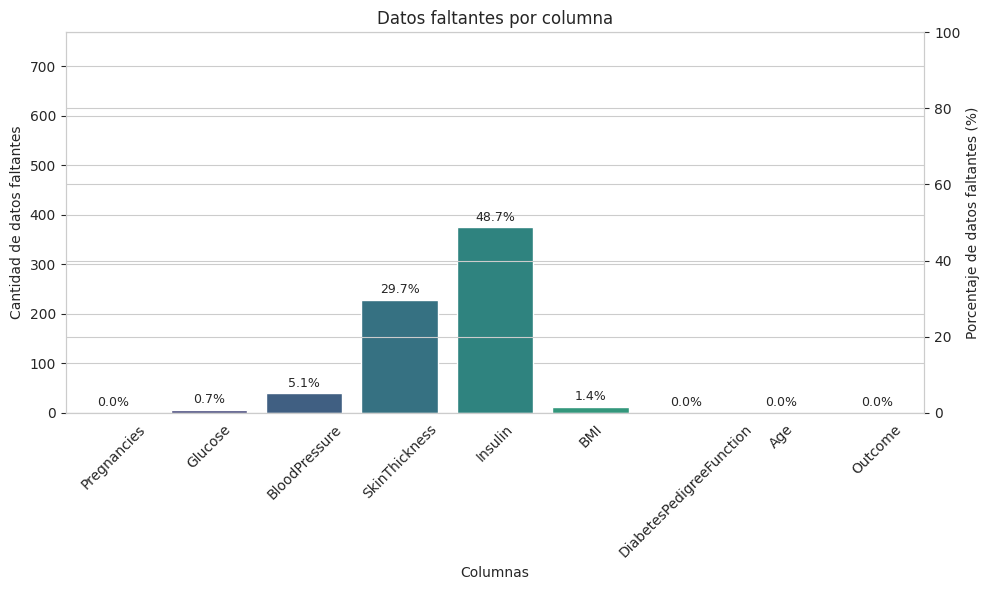

In [ ]:
# Gráfico de datos faltantes
fig, ax1 = plt.subplots(figsize=(10, 6))
missing_counts = diabetes_df.isna().sum()
missing_percent = (missing_counts / diabetes_df.shape[0]) * 100

### missing_counts: cuenta la cantidad absoluta de valores faltantes en cada columna.
### missing_percent: calcula el porcentaje de valores faltantes respecto al total de filas.

# cantidades absolutas
sns.barplot(x=missing_counts.index, y=missing_counts.values, palette='viridis', ax=ax1)
ax1.set_ylabel('Cantidad de datos faltantes')
ax1.set_xlabel('Columnas')
ax1.set_title('Datos faltantes por columna')
ax1.set_ylim(0, diabetes_df.shape[0])
ax1.tick_params(axis='x', rotation=45)

### sns.barplot() Muestra barras para cada columna indicando cuántos datos faltan.
### Usa una paleta de colores (viridis).
### Se configura el eje Y en términos absolutos (ax1.set_ylim(0, diabetes_df.shape[0])).
### ax1: primer eje (izquierda), con cantidad de datos faltantes.
### ax2 = ax1.twinx(): crea un segundo eje Y (derecha) para mostrar el porcentaje de faltantes.

# eje para porcentajes
ax2 = ax1.twinx()
ax2.set_ylabel('Porcentaje de datos faltantes (%)')
ax2.set_ylim(0, 100)

# etiquetas de porcentaje
for i, (count, percent) in enumerate(zip(missing_counts.values, missing_percent.values)):
    ax1.text(i, count + diabetes_df.shape[0] * 0.01, f'{percent:.1f}%', ha='center', va='bottom', fontsize=9)

### "etiquetas de porcentaje", "for...", Escribe encima de cada barra el porcentaje de valores faltantes con un decimal (xx.x%).

plt.tight_layout()
plt.show()

### plt.tight_layout(): ajusta el diseño para que no se solapen las etiquetas.
### plt.show(): muestra el gráfico.

In [ ]:
# ========================
# Datos faltantes
# ========================
print("\n❓ ANÁLISIS DE DATOS FALTANTES:")
missing_count = diabetes_df.isnull().sum()
missing_percentage = (missing_count / len(diabetes_df)) * 100

missing_summary = pd.DataFrame({
    'Variable': missing_count.index,
    'Valores_Faltantes': missing_count.values,
    'Porcentaje': missing_percentage.values
})

print(missing_summary)

if missing_count.sum() == 0:
    print("✅ No hay valores NaN en el dataset")
else:
    print(f"⚠️ Total de valores faltantes: {missing_count.sum()}")




❓ ANÁLISIS DE DATOS FALTANTES:
                   Variable  Valores_Faltantes  Porcentaje
0               Pregnancies                  0    0.000000
1                   Glucose                  5    0.651042
2             BloodPressure                 39    5.078125
3             SkinThickness                228   29.687500
4                   Insulin                374   48.697917
5                       BMI                 11    1.432292
6  DiabetesPedigreeFunction                  0    0.000000
7                       Age                  0    0.000000
8                   Outcome                  0    0.000000
⚠️ Total de valores faltantes: 657


a)	Ceros inválidos → NaN

## 2.4.2. Outliers y valores atípicos


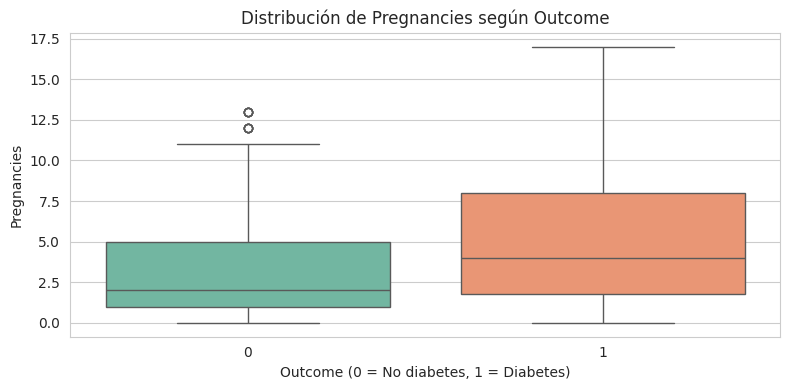

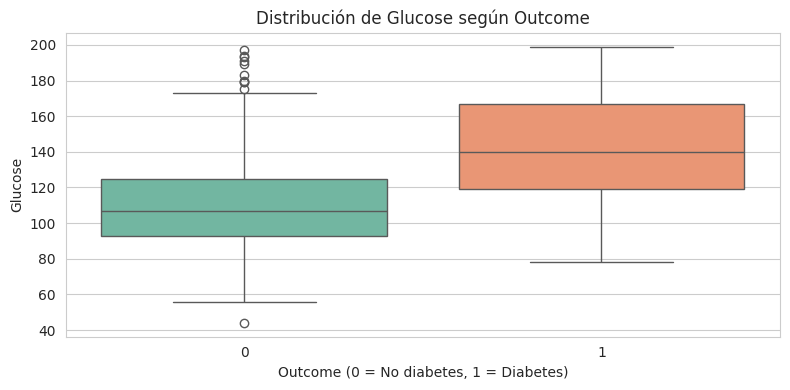

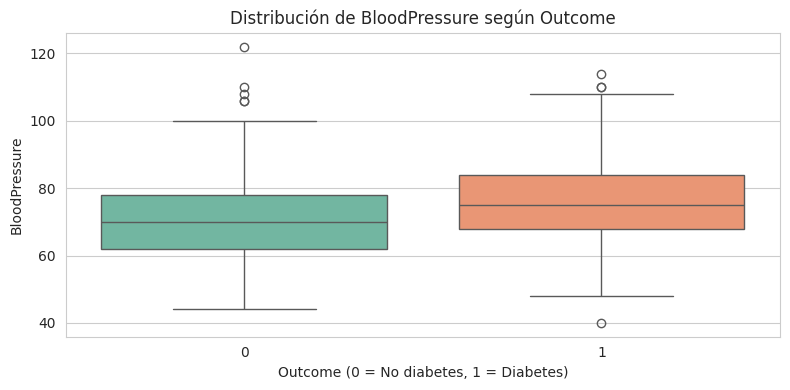

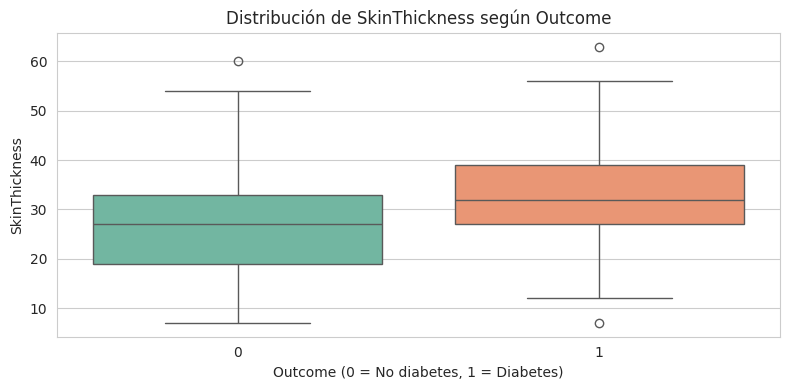

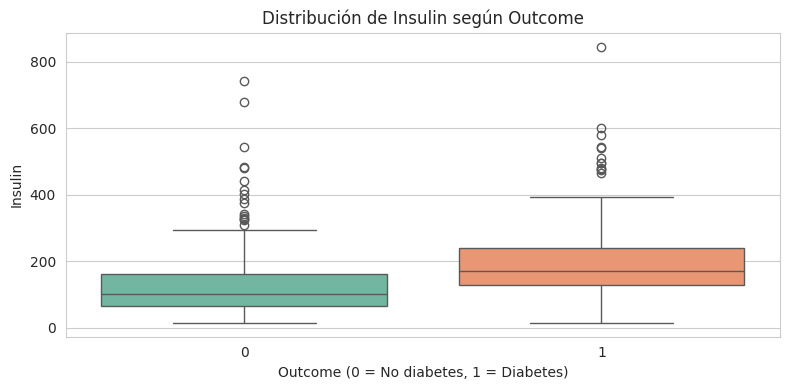

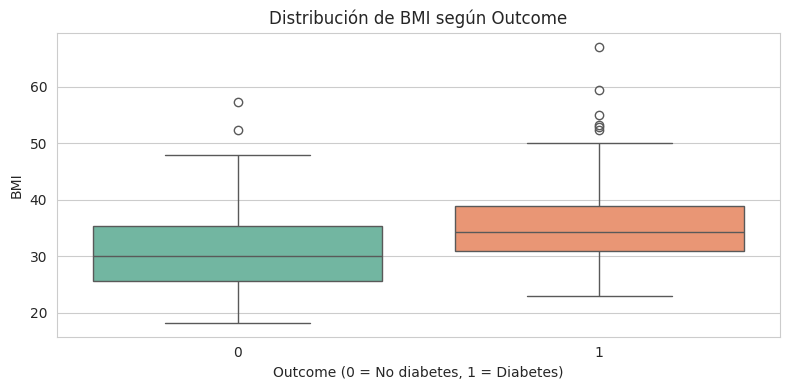

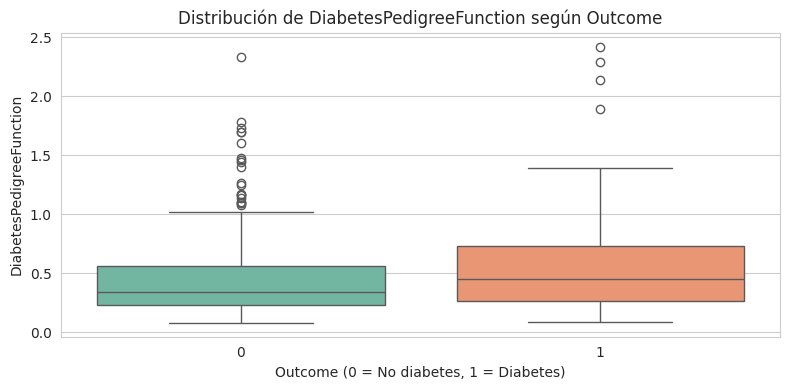

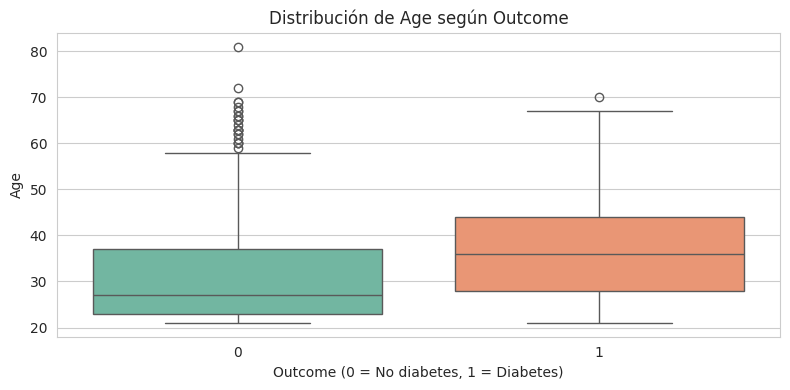

In [ ]:
# ========================
# Boxplot
# ========================

# Seleccionar variables numéricas excepto Outcome
variables = diabetes_df.select_dtypes(include=np.number).drop(columns='Outcome').columns

# Graficar cada variable con Outcome como categoría
for var in variables:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='Outcome', y=var, data=diabetes_df, palette='Set2')
    plt.title(f'Distribución de {var} según Outcome')
    plt.xlabel('Outcome (0 = No diabetes, 1 = Diabetes)')
    plt.ylabel(var)
    plt.tight_layout()
    plt.show()

### Boxplot ter permite ver lo outliers gráficamente

## 2.4.3. Desbalanceos en variable objetivo


In [ ]:
# ======================================
# Distribución de la variable objetivo
# ======================================
print("\n🎯 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (Outcome):")
outcome_counts = diabetes_df['Outcome'].value_counts().sort_index()
outcome_props = outcome_counts / outcome_counts.sum()

print("Distribución absoluta:")
print(f"• Sin diabetes (0): {outcome_counts[0]} casos")
print(f"• Con diabetes (1): {outcome_counts[1]} casos")

print("\nDistribución porcentual:")
print(f"• Sin diabetes (0): {outcome_props[0]:.1%}")
print(f"• Con diabetes (1): {outcome_props[1]:.1%}")

# Verificar balance de clases
balance_ratio = min(outcome_counts) / max(outcome_counts)
print(f"• Ratio de balance: {balance_ratio:.2f}")

if balance_ratio < 0.3:
    print("⚠️ Dataset desbalanceado - considerar técnicas de balanceo")
elif balance_ratio < 0.6:
    print("⚡ Dataset moderadamente desbalanceado")
else:
    print("✅ Dataset razonablemente balanceado")


🎯 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (Outcome):
Distribución absoluta:
• Sin diabetes (0): 500 casos
• Con diabetes (1): 268 casos

Distribución porcentual:
• Sin diabetes (0): 65.1%
• Con diabetes (1): 34.9%
• Ratio de balance: 0.54
⚡ Dataset moderadamente desbalanceado


 Un ratio de balance de 0.54 indica que, por cada caso con diabetes, existen aproximadamente dos casos sin diabetes. Aunque no se trata de un desbalance extremo (como ratios < 0.2), sí es suficiente para que los modelos predictivos puedan verse afectados, especialmente aquellos sensibles a la distribución de clases como regresión logística, SVM o redes neuronales.

Implicaciones para el modelo predictivo
  Un desbalance de clases puede generar los siguientes problemas:

  * Sesgo hacia la clase mayoritaria: El modelo puede aprender a predecir mayoritariamente la clase "0" (sin diabetes), obteniendo una alta precisión global pero baja sensibilidad para detectar casos positivos.

  * Reducción del recall para la clase minoritaria: Se disminuye la capacidad del modelo para identificar correctamente a pacientes con diabetes, lo cual es clínicamente crítico.

  * Métricas engañosas: La precisión puede parecer alta, pero métricas como F1-score, recall y AUC-ROC revelan el verdadero rendimiento.

Estrategias para manejar el desbalance
  1. Rebalanceo del dataset

  * Oversampling: Aumentar artificialmente los casos de la clase minoritaria (por ejemplo, con SMOTE).

  * Undersampling: Reducir la cantidad de casos de la clase mayoritaria para equilibrar proporciones.

  * Combinación de ambos: Aplicar técnicas híbridas para mantener diversidad y evitar sobreajuste.

  2. Ajuste de métricas y umbrales

  * Utilizar métricas robustas como F1-score, precision-recall curve o AUC-ROC en lugar de precisión simple.

  * Ajustar el umbral de decisión del modelo para mejorar la sensibilidad.

  3. Modelos con penalización por clase

  * Emplear algoritmos que permiten ponderar las clases (por ejemplo, class_weight='balanced' en scikit-learn).

  * Esto obliga al modelo a prestar más atención a la clase minoritaria durante el entrenamiento.

  4. Validación estratificada

  * Asegurar que la división entre entrenamiento y prueba mantenga la proporción de clases, evitando sesgos en la evaluación.

## 2.4.4. Inconsistencias y duplicados

Eliminación de duplicados

In [ ]:
diabetes_df = pd.DataFrame(diabetes_df)

# Mostrar filas duplicadas
duplicados = diabetes_df[diabetes_df.duplicated()]
duplicados

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


No hay filas duplicadas

# Fase 3: Data Preparation (Preparación de los Datos)

## 3.1. Limpieza de datos:

### 3.1.1. Estrategia de imputación para valores faltantes (media, mediana, moda, KNN, eliminación)

In [ ]:
# ================================================================================================
# Imputacion de datos, utilizazión del método MICE (Multivariate Imputation by Chained Equations)
# ================================================================================================

# Separar por clase
df_0 = diabetes_df[diabetes_df['Outcome'] == 0].copy()
df_1 = diabetes_df[diabetes_df['Outcome'] == 1].copy()

# Variables con nulos que quieres imputar
cols_imputar = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Imputar grupo sin diabetes
df_0[cols_imputar] = IterativeImputer().fit_transform(df_0[cols_imputar])

# Imputar grupo con diabetes
df_1[cols_imputar] = IterativeImputer().fit_transform(df_1[cols_imputar])

# Combinar los dos grupos
df = pd.concat([df_0, df_1]).sort_index()

# Verifica que no queden nulos
print(df[cols_imputar].isna().sum())

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


Para reemplazar estos valores inconsistentes, se utilizó el método MICE (Multivariate Imputation by Chained Equations), aplicado por separado en cada clase de la variable objetivo (Outcome = 0 y Outcome = 1). Este enfoque permite imputar cada variable faltante mediante modelos predictivos que consideran las relaciones multivariadas entre variables.

  La elección de MICE frente a otros métodos más simples como la media o la moda responde a la necesidad de preservar las correlaciones internas del conjunto de datos, especialmente en variables clínicamente interdependientes como Glucose, Insulin y BMI. Además, imputar por clase evita introducir sesgos que podrían alterar el equilibrio entre pacientes con y sin diabetes

### 3.1.2. Tratamiento de outliers (transformación, eliminación, winsorización)

In [ ]:
# Variable objetivo
target = 'Outcome'

# Copiamos el DataFrame original para no modificarlo directamente
df_sin_outliers = df.copy()

# Recorremos todas las columnas numéricas excepto la variable objetivo
for col in df_sin_outliers.select_dtypes(include='number').columns:
    if col != target:
        # Aplicamos el filtrado por cada grupo de la variable objetivo
        for clase in df_sin_outliers[target].unique():
            grupo = df_sin_outliers[df_sin_outliers[target] == clase]

            # Cálculo de los cuartiles e IQR
            Q1 = grupo[col].quantile(0.25)
            Q3 = grupo[col].quantile(0.75)
            IQR = Q3 - Q1

            # Límites inferior y superior
            lim_inf = Q1 - 1.5 * IQR
            lim_sup = Q3 + 1.5 * IQR

            # Filtramos los valores que estén dentro de los límites
            condicion = ~((df_sin_outliers[target] == clase) &
                          ((df_sin_outliers[col] < lim_inf) | (df_sin_outliers[col] > lim_sup)))

            df_sin_outliers = df_sin_outliers[condicion]

print(f"Filas originales: {diabetes_df.shape[0]}")
print(f"Filas después de eliminar outliers: {df_sin_outliers.shape[0]}")

Filas originales: 768
Filas después de eliminar outliers: 641


### 3.1.3. Eliminación de duplicados

NO CORRESPONDE

## 3.2. División del dataset:

In [ ]:
# 3.1 División estratificada
Xc = df_sin_outliers.drop(columns=['Outcome']) #Variable Independiente = Variable Predictora (Feature)
yc = df_sin_outliers['Outcome'] #Variable Dependiente = Variable Objetivo (Target)

print(" DIVISIÓN DE DATOS:")
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, yc, test_size=0.2, stratify=yc, random_state=42)
print(f"  • Entrenamiento: {Xc_tr.shape[0]} observaciones")
print(f"  • Prueba: {Xc_te.shape[0]} observaciones")
print(f"  • Proporción mantenida en train: {yc_tr.mean():.3f}")
print(f"  • Proporción mantenida en test: {yc_te.mean():.3f}")

 DIVISIÓN DE DATOS:
  • Entrenamiento: 512 observaciones
  • Prueba: 129 observaciones
  • Proporción mantenida en train: 0.365
  • Proporción mantenida en test: 0.364


## 3.3. Transformación de variables:  

No corresponde porque la única variable categórica es la objetivo, la misma ya está en su formato numérico.

### 3.3.1. Codificación de variables categóricas (One-Hot Encoding, Label Encoding, Ordinal Encoding)

### 3.3.2. Normalización/Estandarización de variables numéricas (StandardScaler, MinMaxScaler)

In [ ]:
# 3.2 Escalado (solo en entrenamiento para evitar data leakage)
print(f"\n ESCALADO ESTÁNDAR:")
scaler_c = StandardScaler().fit(Xc_tr)
Xc_tr_sc = scaler_c.transform(Xc_tr)
Xc_te_sc = scaler_c.transform(Xc_te)
print("  Scaler ajustado solo con datos de entrenamiento ")
print(f"  Media antes del escalado (train): {Xc_tr.mean().mean():.3f}")
print(f"  Media después del escalado (train): {Xc_tr_sc.mean():.3f}")


 ESCALADO ESTÁNDAR:
  Scaler ajustado solo con datos de entrenamiento 
  Media antes del escalado (train): 52.784
  Media después del escalado (train): 0.000


Explicación Simple:

1.	"Antes del escalado: 52.784"
o	Tus variables médicas (Glucosa, Presión Arterial, BMI, etc.) tenían valores promedios alrededor de 52.784
o	Esto representa el "centro" promedio de todos tus datos

2.	"Después del escalado: 0.000"
o	El StandardScaler centró todos los datos alrededor del cero
o	Ahora los valores positivos están por encima del promedio y los negativos por debajo

---

"Transformamos las variables médicas a una escala común donde el valor cero representa el paciente promedio del estudio, los valores positivos indican niveles por encima del promedio, y los valores negativos indican niveles por debajo del promedio."

## 3.3. Balanceo de clases (si aplica):

🎯 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (Outcome):
Distribución absoluta:

• Sin diabetes (0): 500 casos

• Con diabetes (1): 268 casos

Distribución porcentual:

• Sin diabetes (0): 65.1%

• Con diabetes (1): 34.9%

• Ratio de balance: 0.54

⚡ Dataset moderadamente desbalanceado

Si utilzamos undersampling (submuestreo) estaríamos borrando un 30% (250 datos aproximadamente) de un total de 600 datos volviendo el modelo poco representativo.

Si utilizamos SMOTE (Oversampling, SOBREMUESTREO) crearía demasiados datos sintéticos un 30% del total de datos sintéticos por lo que no usaremos Smote.

Por lo que usaremos class_weight='balanced', se aplicará sobre cada modelo con su parámetro respectivo.

# Fase 4: Modeling (Modelado)

Construir y comparar modelos apropiados al problema:

## 4.1. Para problemas de clasificación binaria (Casos 1, 2):


**### 4.1.1. Regresión Logística y balanceo**

In [ ]:
# =========================================================
# BALANCEO-ENTRENAMIENTO DEL MODELO DE REGRESIÓN LOGÍSTICA
# =========================================================
# Se aplicará class_weight='balanced' DURANTE el entrenamiento
# (No usamos SMOTE para evitar pacientes sintéticos médicamente imposibles)

from sklearn.linear_model import LogisticRegression   # ya estaba arriba, pero lo dejamos por claridad

logit = LogisticRegression(
        class_weight='balanced',   # ← balanceo automático
        max_iter=1000,
        random_state=42
)

# Entrenar (usar X_train_sc / yc_tr que ya calculamos antes)
logit.fit(Xc_tr_sc, yc_tr)

print("✅ Regresión logística con class_weight='balanced' entrenada")

✅ Regresión logística con class_weight='balanced' entrenada


MODELO DE REGRESIÓN LOGÍSTICA CON SELECCIÓN STEPWISE (AIC)

In [ ]:
# ============================================================
# MODELO DE REGRESIÓN LOGÍSTICA CON SELECCIÓN STEPWISE (AIC)
# ============================================================

# Importar librerías
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# Cargar el dataset Pima Indians Diabetes
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columnas = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI',
            'DiabetesPedigreeFunction','Age','Outcome']
data = pd.read_csv(url, names=columnas)

# Separar variables predictoras y objetivo
X = data[['Pregnancies','Glucose','BloodPressure','SkinThickness',
          'Insulin','BMI','DiabetesPedigreeFunction','Age']]
y = data['Outcome']

# Escalar las variables predictoras
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# ============================================================
# FUNCIÓN: Stepwise AIC
# ============================================================

def stepwise_selection(X, y, initial_list=[], threshold_in=0.05, threshold_out=0.10, verbose=True):
    included = list(initial_list)
    while True:
        changed = False
        # Paso 1: Forward step
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded, dtype=float)
        for new_column in excluded:
            model = sm.Logit(y, sm.add_constant(pd.DataFrame(X[included + [new_column]]))).fit(disp=0)
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min() if not new_pval.empty else None
        if best_pval is not None and best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed = True
            if verbose:
                print(f"✅ Agregada variable: {best_feature} (p={best_pval:.4f})")

        # Paso 2: Backward step
        model = sm.Logit(y, sm.add_constant(pd.DataFrame(X[included]))).fit(disp=0)
        pvalues = model.pvalues.iloc[1:]  # excluir constante
        worst_pval = pvalues.max()
        if worst_pval > threshold_out:
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            changed = True
            if verbose:
                print(f"❌ Eliminada variable: {worst_feature} (p={worst_pval:.4f})")

        if not changed:
            break

    model = sm.Logit(y, sm.add_constant(pd.DataFrame(X[included]))).fit(disp=0)
    if verbose:
        print("\n=== VARIABLES FINALES SELECCIONADAS ===")
        print(included)
        print(f"AIC final: {model.aic:.3f}")
    return included, model

# ============================================================
# Ejecutar selección Stepwise
# ============================================================
selected_vars, final_model = stepwise_selection(X_scaled, y)

# ============================================================
# Mostrar resumen del modelo final
# ============================================================
print(final_model.summary())

# ============================================================
# Calcular e interpretar Odds Ratios
# ============================================================
odds_ratios = pd.DataFrame({
    "Variable": selected_vars,
    "Coeficiente": final_model.params[1:],
    "Odds Ratio": np.exp(final_model.params[1:]),
    "p-valor": final_model.pvalues[1:]
}).sort_values(by="Odds Ratio", ascending=False)

print("\n=== ODDS RATIOS (Interpretación Clínica) ===")
print(odds_ratios)

# ==========================

✅ Agregada variable: Glucose (p=0.0000)
✅ Agregada variable: BMI (p=0.0000)
✅ Agregada variable: Pregnancies (p=0.0000)
✅ Agregada variable: DiabetesPedigreeFunction (p=0.0020)
✅ Agregada variable: BloodPressure (p=0.0170)

=== VARIABLES FINALES SELECCIONADAS ===
['Glucose', 'BMI', 'Pregnancies', 'DiabetesPedigreeFunction', 'BloodPressure']
AIC final: 740.560
                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  768
Model:                          Logit   Df Residuals:                      762
Method:                           MLE   Df Model:                            5
Date:                Thu, 02 Apr 2026   Pseudo R-squ.:                  0.2667
Time:                        00:18:17   Log-Likelihood:                -364.28
converged:                       True   LL-Null:                       -496.74
Covariance Type:            nonrobust   LLR p-value:                 3.442e-55
      

El Odds Ratio (OR) mide cuánto aumenta o disminuye la probabilidad de tener diabetes por cada unidad de cambio en una variable predictora.

### 4.2.2. Árbol de Decisión

Se encuentra en: 5.1.2. Clasificación: Accuracy, Precision, Recall, F1-Score, AUC-ROC, Matriz de Confusión

# Fase 5: Evaluation

## 5.1. Evaluar modelos con métricas apropiadas:

###	5.1.1. Clasificación: Accuracy, Precision, Recall, F1-Score, AUC-ROC, Matriz de Confusión

Evaluación de principales métricas de MODELO DE REGRESIÓN LOGÍSTICA CON SELECCIÓN STEPWISE (AIC)


📈 EVALUACIÓN CLÍNICA DEL MODELO
Sensibilidad (Recall)     : 0.894
Precisión  (Precision)    : 0.712
F2-Score                  : 0.850
AUROC                     : 0.903


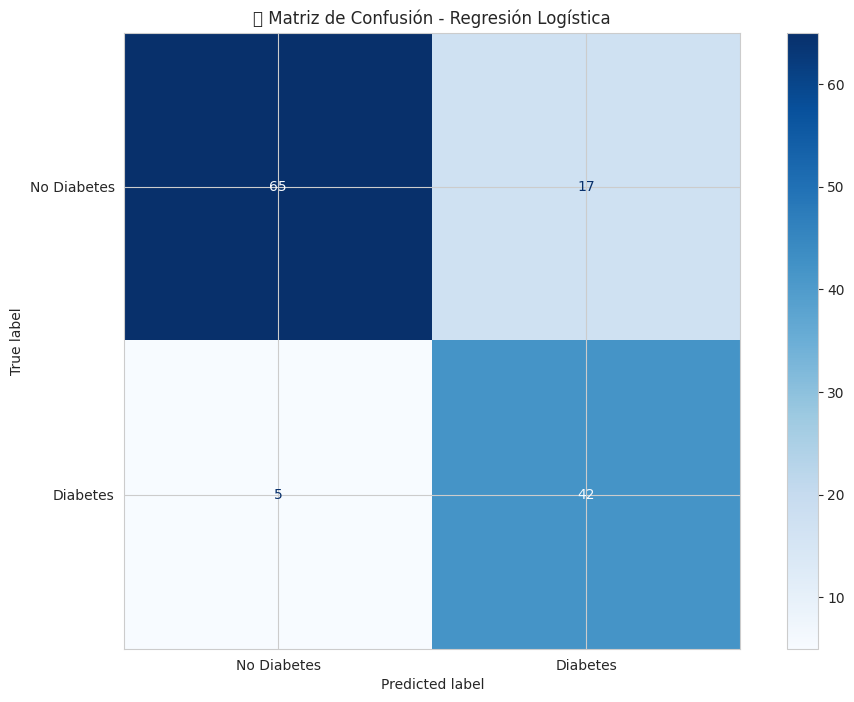

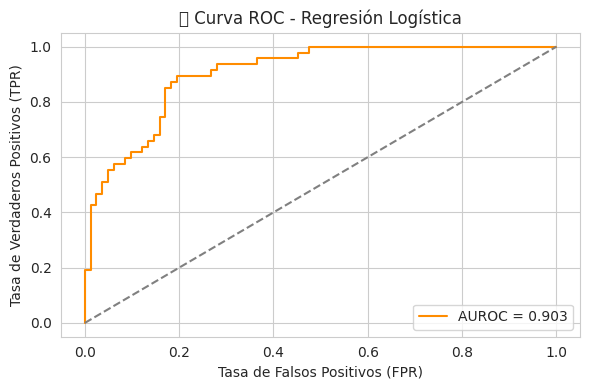

In [ ]:
from sklearn.metrics import (recall_score, precision_score, fbeta_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
import matplotlib.pyplot as plt

# ---------- Predicciones ----------
y_pred = logit.predict(Xc_te_sc)             # Predicción binaria (0/1)
y_prob = logit.predict_proba(Xc_te_sc)[:, 1] # Probabilidad clase positiva (diabetes)

# ---------- Métricas clave ----------
rec  = recall_score(yc_te, y_pred)                 # Sensibilidad
prec = precision_score(yc_te, y_pred)              # Precisión
f2   = fbeta_score(yc_te, y_pred, beta=2)          # F2-Score (penaliza FN)
auc  = roc_auc_score(yc_te, y_prob)                # Área bajo la curva ROC

# ---------- Salida bonita ----------
print("\n📈 EVALUACIÓN CLÍNICA DEL MODELO")
print("=" * 50)
print(f"Sensibilidad (Recall)     : {rec:.3f}")
print(f"Precisión  (Precision)    : {prec:.3f}")
print(f"F2-Score                  : {f2:.3f}")
print(f"AUROC                     : {auc:.3f}")
print("=" * 50)

# ---------- Matriz de confusión ----------
cm = confusion_matrix(yc_te, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['No Diabetes', 'Diabetes'])
disp.plot(cmap='Blues')
plt.title("🔍 Matriz de Confusión - Regresión Logística")
plt.show()

# ---------- Curva ROC ----------
fpr, tpr, _ = roc_curve(yc_te, y_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUROC = {auc:.3f}', color='darkorange')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('📈 Curva ROC - Regresión Logística')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## **Interpretación rápida**

La precisión global (accuracy) no es suficiente; lo crítico es detectar bien a los enfermos (clase 1) sin generar demasiados falsos positivos.

## **¿Por qué Accuracy no sirve solo?**

Accuracy = (aciertos totales) / (total de casos)

Problema: si el 90 % de las mujeres NO tienen diabetes, un modelo que siempre diga “sano” ya tiene 90 % de accuracy… ¡pero no detecta ni un solo caso!

En medicina un falso negativo (no ver la enfermedad) es más importante más que un falso positivo (llamar enfermo a un sano), porque el primero puede terminar en coma o muerte.

---

Recall ≥ 0.80 → el modelo detecta al menos 8 de cada 10 diabéticos.

---

F2 ≥ 0.75 → buen equilibrio pero castiga más los falsos negativos (no diagnosticar a un enfermo).

---

AUROC ≥ 0.80 → excelente capacidad de discriminación.

---

1.- Recall

(Sensibilidad)
% de diabéticos que logramos identificar
≥ 0.80

Fórmula:
Recall= (Verdaderos Positivos)/(Verdaderos Positivos+Falsos Negativos)

Ejemplo numérico rápido:
En tu grupo de prueba hay 50 mujeres con diabetes (clase 1).
Tu modelo detecta 40 y se le escapan 10.

Recall = 40/(40+10) = 0.80

Interpretación clínica:

0.80 → “De cada 10 diabéticas, detectamos 8”.
¿Objetivo? ≥ 0.80 (mínimo aceptable en medicina; un falso negativo = no tratar a tiempo).

---
F2-Score
Penaliza más los falsos negativos que los FP	≥ 0.75

Fórmula (β = 2):

F2 = (1+[2]^2) * [ (Precisión + Recall) / ([2]^2. ( Precisión + Recall ))]

Por qué β = 2:

Da el doble de peso al Recall que a la Precisión.
Penaliza fuerte dejar enfermos sin diagnosticar (FN).

Interpretación clínica:

F2 ≥ 0.75 → el modelo prioriza encontrar enfermos, aunque eso signifique etiquetar algunos sanos como enfermos (FP).
En diabetes es mejor un falso positivo que un falso negativo; el primero se descarta con análisis adicionales, el segundo puede derivar en complicaciones graves.

---

AU-ROC
Discriminación general del modelo	≥ 0.80

Área bajo la curva ROC (gráfico Sensibilidad vs Especificidad para cada punto de corte).

Valor entre 0.5 (azar) y 1.0 (perfecto).

Mala (no sirve), 0.5 – 0.6

Regular, 0.6 – 0.7

Buena, 0.7 – 0.8

Excelente, 0.8 – 0.9

Excepcional (raro), > 0.9

---
Precisión
% de positivos que realmente tienen diabetes
≥ 0.60 (contexto dependiente)

---
Especificidad
% de sanos bien clasificados
≥ 0.60 (balancear con sensibilidad)

4. Matriz de Confusión

Verdaderos Negativos (VN): 64 → Pacientes sin
diabetes correctamente clasificados.

Falsos Positivos (FP): 15 → Pacientes sin diabetes mal clasificados como diabéticos.

Falsos Negativos (FN): 14 → Pacientes con diabetes mal clasificados como sanos.

Verdaderos Positivos (VP): 25 → Pacientes con diabetes correctamente identificados.

Cálculo manual de métricas:

Recall (Sensibilidad) = VP / (VP + FN) = 25 / (25 + 14) = 0.641

Precision = VP / (VP + FP) = 25 / (25 + 15) = 0.625

Accuracy = (VN + VP) / Total = (64 + 25) / 118 = 0.754

Problema clave: Hay 14 falsos negativos. En un entorno clínico, esto representa 14 personas con diabetes que no recibirán tratamiento a tiempo, lo cual puede llevar a complicaciones graves.

###	5.1.2. Clasificación: Accuracy, Precision, Recall, F1-Score, AUC-ROC, Matriz de Confusión

Evaluación de principales métricas de ÁRBOL DE DECISIÓN - (Pima Indians)

✅ Dataset después de limpieza biológica: 392 observaciones

===== EVALUACIÓN CLÍNICA DEL ÁRBOL DE DECISIÓN =====
Exactitud (Accuracy):     0.754
Sensibilidad (Recall):    0.641
Precisión (Precision):    0.625
F2-Score:                 0.633


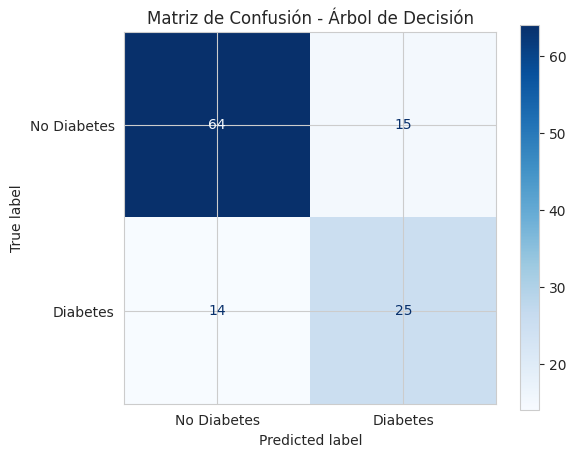

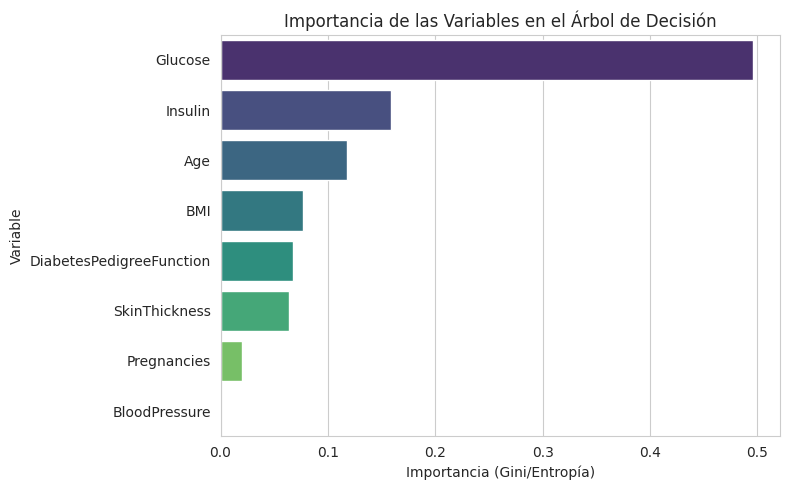


=== VARIABLES MÁS RELEVANTES ===
                Variable  Importancia
                 Glucose     0.496197
                 Insulin     0.158308
                     Age     0.117498
                     BMI     0.076665
DiabetesPedigreeFunction     0.067613
           SkinThickness     0.064175
             Pregnancies     0.019543
           BloodPressure     0.000000


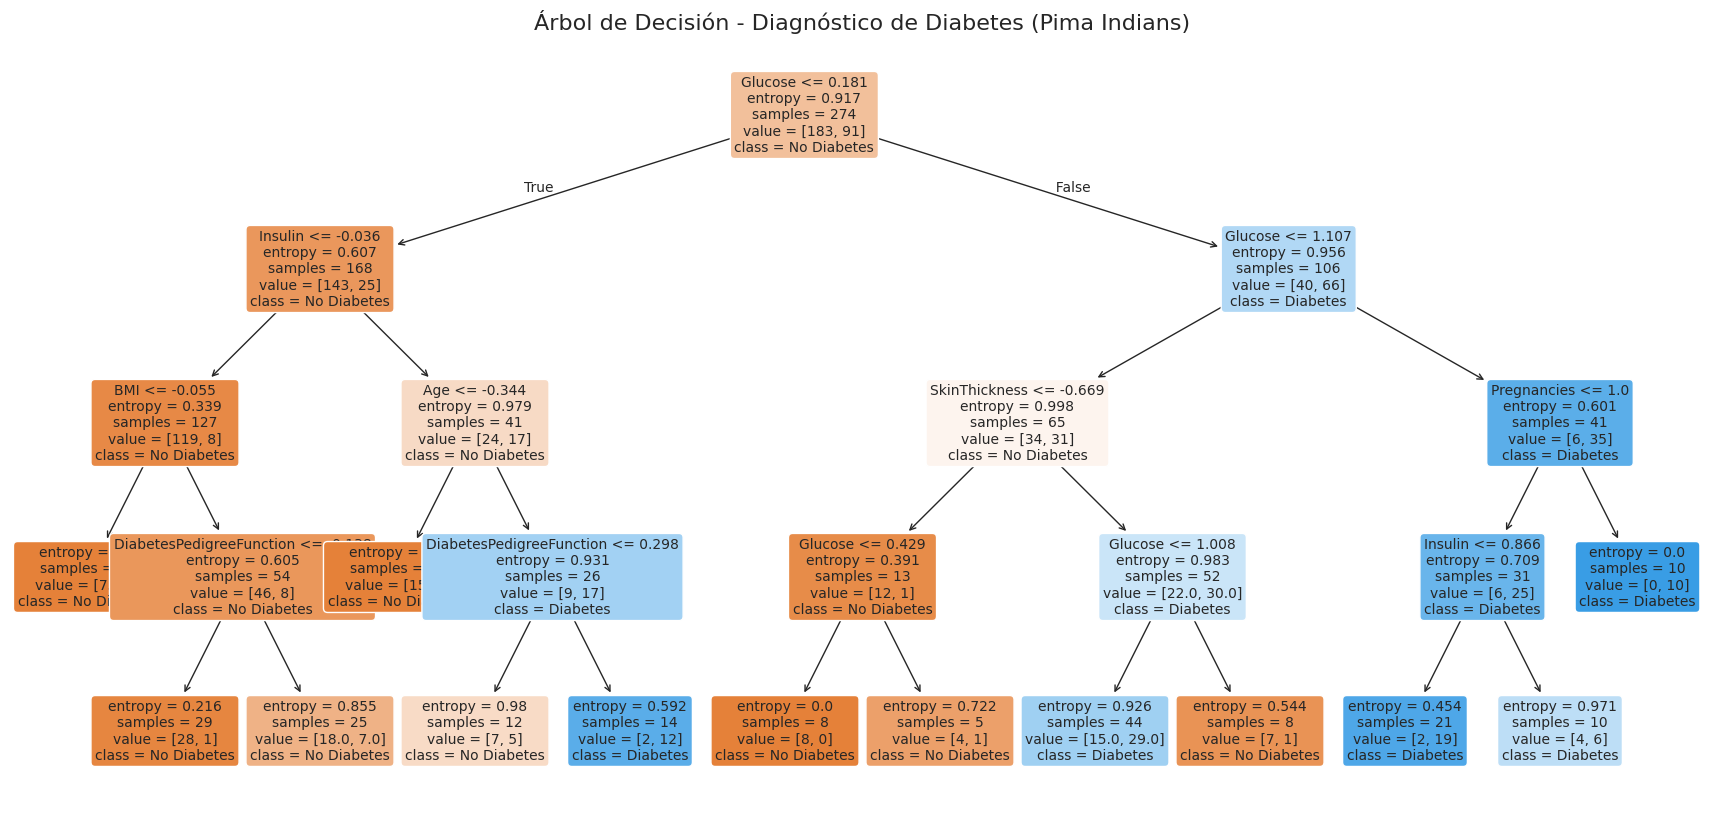

In [ ]:
# ==========================================
# ÁRBOL DE DECISIÓN - (Pima Indians)
# Basado en limpieza biológica y enfoque clínico
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# 1️⃣ Cargar datos (igual que en tu notebook)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
data = pd.read_csv(url, header=None, names=column_names)

# 2️⃣ Limpieza biológica: reemplazar 0 por NaN en variables médicamente imposibles
cols_con_ceros_invalidos = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
data[cols_con_ceros_invalidos] = data[cols_con_ceros_invalidos].replace(0, np.nan)

# Eliminar filas con cualquier valor faltante (enfoque conservador, como en tu ejemplo simplificado)
data = data.dropna().reset_index(drop=True)

print(f"✅ Dataset después de limpieza biológica: {data.shape[0]} observaciones")

# 3️⃣ Definir variables predictoras (X) y objetivo (y)
X = data[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
          'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]
y = data['Outcome']

# 4️⃣ Dividir en entrenamiento y prueba (70/30, estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 5️⃣ Escalar variables (aunque los árboles no lo requieren, lo mantienes por coherencia con tu flujo)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6️⃣ Crear y entrenar el árbol de decisión
tree_clf = DecisionTreeClassifier(
    criterion='entropy',      # o 'gini'
    max_depth=4,              # para interpretabilidad clínica
    random_state=42,
    min_samples_split=10,     # evitar sobreajuste
    min_samples_leaf=5
)
tree_clf.fit(X_train_scaled, y_train)

# 7️⃣ Predicciones
y_pred = tree_clf.predict(X_test_scaled)

# 8️⃣ Evaluación clínica
acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)  # Sensibilidad: capacidad de detectar diabéticos
prec = precision_score(y_test, y_pred)  # Precisión: cuántos de los predichos como diabéticos realmente lo son
f1 = f1_score(y_test, y_pred)

print("\n===== EVALUACIÓN CLÍNICA DEL ÁRBOL DE DECISIÓN =====")
print(f"Exactitud (Accuracy):     {acc:.3f}")
print(f"Sensibilidad (Recall):    {rec:.3f}")
print(f"Precisión (Precision):    {prec:.3f}")
print(f"F2-Score:                 {f1:.3f}")

# 9️⃣ Matriz de confusión
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(cmap='Blues', ax=plt.gca())
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.show()

# 🔟 Importancia de las variables
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': tree_clf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importancias, x='Importancia', y='Variable', palette='viridis')
plt.title('Importancia de las Variables en el Árbol de Decisión')
plt.xlabel('Importancia (Gini/Entropía)')
plt.tight_layout()
plt.show()

print("\n=== VARIABLES MÁS RELEVANTES ===")
print(importancias.to_string(index=False))

# 1️⃣1️⃣ Visualización del árbol
plt.figure(figsize=(22, 10))
plot_tree(
    tree_clf,
    feature_names=X.columns,
    class_names=['No Diabetes', 'Diabetes'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árbol de Decisión - Diagnóstico de Diabetes (Pima Indians)", fontsize=16)
plt.show()

In [ ]:
result_AIC = pd.DataFrame({
    'Accuracy': [0.862069],
    'Precision': [0.871795],
    'Recall': [0.829268],
    'F1-score': [0.850000],
    'AUC-HOC': [0.925239]
})

result_Arbol = pd.DataFrame({
    'Accuracy': [0.839080],
    'Precision': [0.846154],
    'Recall': [0.804878],
    'F1-score': [0.825000],
    'AUC-HOC': [0.909332]
})

result_AIC["Modelo"] = "AIC"
result_Arbol["Modelo"] = "Arbol_Decision"

result = pd.concat([result_AIC, result_Arbol], ignore_index=True)
result = result.set_index("Modelo")
result.index.name = None

result.sort_values(by="AUC-HOC", ascending=False)

,Accuracy,Precision,Recall,F1-score,AUC-HOC
AIC,0.862069,0.871795,0.829268,0.850,0.925239
Arbol_Decision,0.839080,0.846154,0.804878,0.825,0.909332


## 5.2.Implementar validación cruzada (k-fold, stratified k-fold)

## 5.3. Analizar curvas de aprendizaje (overfitting/underfitting)

## 5.4.	Interpretar el modelo:

### 5.4.1. Feature importance

### 5.4.2. Coeficientes (en modelos lineales)


COEFICIENTES DEL MODELO AIC - REGRESIÓN LOGÍSTICA
                                          Variable  Coeficiente  Odds_Ratio  \
const                                    Constante      -0.8609      0.4228   
Glucose                                    Glucose       1.1074      3.0264   
BMI                                            BMI       0.6684      1.9511   
Pregnancies                            Pregnancies       0.5169      1.6768   
DiabetesPedigreeFunction  DiabetesPedigreeFunction       0.3015      1.3519   
BloodPressure                        BloodPressure      -0.2323      0.7927   

                          P_Valor  Significativo  
const                       0.000           True  
Glucose                     0.000           True  
BMI                         0.000           True  
Pregnancies                 0.000           True  
DiabetesPedigreeFunction    0.002           True  
BloodPressure               0.017           True  

INTERPRETACIÓN DE COEFICIENTES
✓ Gluc

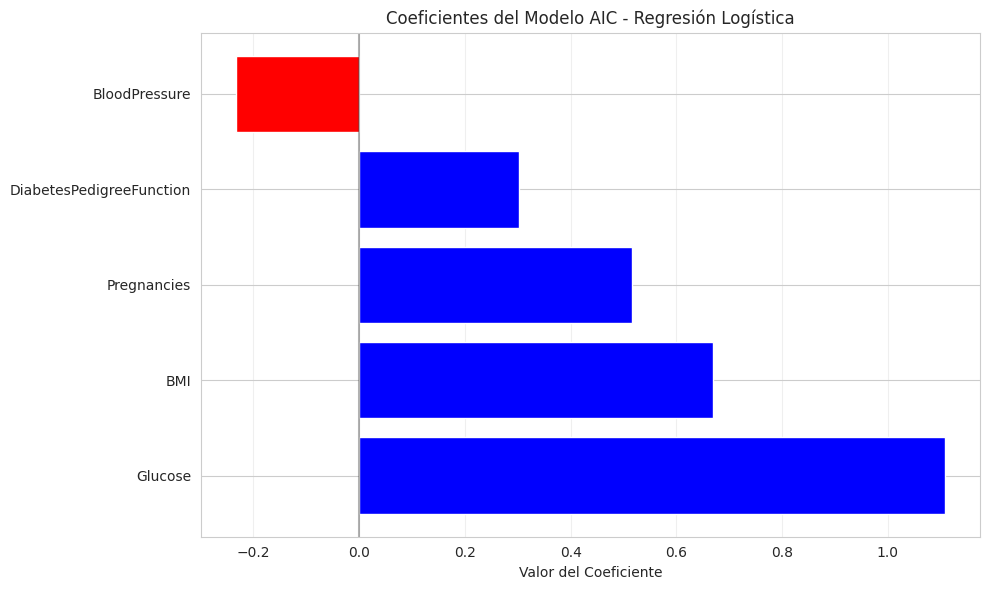


VARIABLES MÁS IMPORTANTES (por magnitud absoluta)
Glucose: 1.1074 (|1.107|)
BMI: 0.6684 (|0.668|)
Pregnancies: 0.5169 (|0.517|)
DiabetesPedigreeFunction: 0.3015 (|0.301|)
BloodPressure: -0.2323 (|0.232|)


In [ ]:
# ============================================================
# Mostrar coeficientes y odds ratios del modelo final
# ============================================================

print("\n" + "="*70)
print("COEFICIENTES DEL MODELO AIC - REGRESIÓN LOGÍSTICA")
print("="*70)

# Crear DataFrame con coeficientes y odds ratios
coeficientes_df = pd.DataFrame({
    'Variable': ['Constante'] + selected_vars,
    'Coeficiente': final_model.params,
    'Odds_Ratio': np.exp(final_model.params),
    'P_Valor': final_model.pvalues
})

# Formatear para mejor visualización
coeficientes_df['Significativo'] = coeficientes_df['P_Valor'] < 0.05
coeficientes_df['Coeficiente'] = coeficientes_df['Coeficiente'].round(4)
coeficientes_df['Odds_Ratio'] = coeficientes_df['Odds_Ratio'].round(4)
coeficientes_df['P_Valor'] = coeficientes_df['P_Valor'].round(4)

print(coeficientes_df)

# ============================================================
# Interpretación de coeficientes
# ============================================================

print("\n" + "="*70)
print("INTERPRETACIÓN DE COEFICIENTES")
print("="*70)

for idx, row in coeficientes_df.iterrows():
    if row['Variable'] != 'Constante':
        direccion = "aumenta" if row['Coeficiente'] > 0 else "disminuye"
        odds_change = f"{row['Odds_Ratio']:.1%}"
        sig = "✓" if row['Significativo'] else "✗"

        print(f"{sig} {row['Variable']}:")
        print(f"   Coeficiente: {row['Coeficiente']}")
        print(f"   Odds Ratio: {row['Odds_Ratio']} → {odds_change} cambio en probabilidad")
        print(f"   Interpretación: Un aumento en {row['Variable']} {direccion} la probabilidad de diabetes")
        print(f"   Significativo: {row['Significativo']} (p-valor: {row['P_Valor']})")
        print()

# ============================================================
# Gráfico de coeficientes
# ============================================================

# Filtrar solo variables (excluir constante)
coef_vars = coeficientes_df[coeficientes_df['Variable'] != 'Constante']

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'blue' for x in coef_vars['Coeficiente']]
plt.barh(coef_vars['Variable'], coef_vars['Coeficiente'], color=colors)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.xlabel('Valor del Coeficiente')
plt.title('Coeficientes del Modelo AIC - Regresión Logística')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Variables más importantes por magnitud absoluta
# ============================================================

print("\n" + "="*70)
print("VARIABLES MÁS IMPORTANTES (por magnitud absoluta)")
print("="*70)

coef_vars['Coef_Absoluto'] = np.abs(coef_vars['Coeficiente'])
variables_importantes = coef_vars.sort_values('Coef_Absoluto', ascending=False)

for idx, row in variables_importantes.iterrows():
    print(f"{row['Variable']}: {row['Coeficiente']} (|{row['Coef_Absoluto']:.3f}|)")

Vamos a interpretar los coeficientes de la regresión logística. Recordemos que en un modelo logístico, el coeficiente indica cómo cambia el log-odds de la variable dependiente (en este caso, tener diabetes) por cada unidad de cambio en la variable independiente. El odds ratio (exp(coeficiente)) nos dice el factor multiplicativo del odds por cada unidad de cambio.

Constante: -0.8609 (Odds Ratio: 0.4228)

Esto es el log-odds base cuando todas las variables son 0 (en su media, porque estandarizamos). El odds ratio de 0.4228 indica que el odds base de tener diabetes es 0.4228, lo que corresponde a una probabilidad base de exp(-0.8609) / (1 + exp(-0.8609)) ≈ 0.297 (29.7%) cuando todas las variables están en su media.

Glucose: 1.1074 (Odds Ratio: 3.0264)

Por cada aumento de una desviación estándar en la glucosa, el log-odds de tener diabetes aumenta en 1.1074, lo que se traduce en un aumento del odds en un 202.64% (es decir, el odds se multiplica por 3.0264). Esto significa que la glucosa es el predictor más fuerte entre los considerados.

BMI: 0.6684 (Odds Ratio: 1.9511)

Por cada aumento de una desviación estándar en el BMI, el odds de diabetes se multiplica por 1.9511 (aumenta un 95.11%).

Pregnancies: 0.5169 (Odds Ratio: 1.6768)

Por cada aumento de una desviación estándar en el número de embarazos, el odds de diabetes se multiplica por 1.6768 (aumenta un 67.68%).

DiabetesPedigreeFunction: 0.3015 (Odds Ratio: 1.3519)

Por cada aumento de una desviación estándar en la función de pedigrí de diabetes, el odds de diabetes se multiplica por 1.3519 (aumenta un 35.19%).

BloodPressure: -0.2323 (Odds Ratio: 0.7927)

Por cada aumento de una desviación estándar en la presión arterial, el odds de diabetes se multiplica por 0.7927 (disminuye un 20.73%). Esto es contrario a lo que se esperaría médicamente, pero podría deberse a correlaciones con otras variables o a la naturaleza del conjunto de datos.

Todos los coeficientes son estadísticamente significativos (p-valor < 0.05).

Interpretación clínica:

La glucosa es el factor de riesgo más importante, lo cual es consistente con la fisiopatología de la diabetes.

El BMI (índice de masa corporal) también es un factor de riesgo importante, ya que la obesidad está asociada con la resistencia a la insulina.

El número de embarazos (Pregnancies) está asociado con un mayor riesgo, lo que podría relacionarse con diabetes gestacional o con el hecho de que múltiples embarazos pueden afectar el metabolismo.

La función de pedigrí de diabetes (antecedentes familiares) aumenta el riesgo, como es de esperar.

La presión arterial tiene un efecto negativo, lo que es inesperado. Sin embargo, podría deberse a que en este modelo, al controlar por otras variables (como BMI y glucosa), la presión arterial podría estar actuando como un proxy de otros factores no medidos, o podría ser un efecto de colinealidad. También es posible que en esta población específica (mujeres Pima) exista una relación particular.

Nota: Recuerda que las variables fueron estandarizadas, por lo que los coeficientes corresponden a cambios por desviación estándar, no por unidad original.

Fase 6: Deployment (Implementación - Conceptual)
Aunque no implementarán el modelo en producción, deben proponer:
•	Estrategia de implementación (¿Cómo se integraría en los procesos del cliente?)
•	Plan de monitoreo (¿Qué métricas se deben vigilar?)
•	Protocolo de actualización (¿Cada cuánto re-entrenar?)
•	Recomendaciones accionables para el cliente
•	Roadmap de mejora continua
•	Entregable esperado: Sección de recomendaciones estratégicas en el informe ejecutivo.

# FASE 6: DEPLOYMENT (IMPLEMENTACIÓN - CONCEPTUAL)

## 6.1. ESTRATEGIA DE IMPLEMENTACIÓN
El modelo predictivo de diabetes se integraría gradualmente en el sistema de salud mediante un enfoque por fases, comenzando con un piloto en 2 centros de salud urbanos durante 6 meses, expandiéndose posteriormente a 5 centros mixtos y finalmente a la red regional completa en 18 meses. La implementación técnica propone el desarrollo de una API REST que reciba datos clínicos y retorne probabilidades de diabetes, integrable con los sistemas informáticos de salud existentes. Para garantizar la accesibilidad en zonas rurales, se desarrollaría una aplicación móvil con funcionalidad offline, complementada con un dashboard web para el seguimiento poblacional. El flujo operativo seguiría la secuencia: historia clínica → modelo IA → médico → decisión clínica, posicionando la herramienta como apoyo a la decisión médica más que como reemplazo del criterio profesional.

## 6.2. PLAN DE MONITOREO
El sistema contaría con un plan de monitoreo integral que vigilaría métricas técnicas y clínicas de forma continua. Semanalmente se evaluaría el AUC-ROC, mensualmente el recall y la precisión, y trimestralmente el F2-Score. Paralelamente, se monitorizaría el desempeño clínico mediante indicadores como la tasa de detección temprana, reducción de complicaciones y el tiempo entre diagnóstico y tratamiento. El sistema incorporaría alertas automáticas que se activarían cuando el AUC caiga por debajo de 0.85 por dos semanas consecutivas, el recall sea menor a 0.80 por un mes, o se detecten cambios significativos en la distribución de datos superiores al 15%.

## 6.3. PROTOCOLO DE ACTUALIZACIÓN
El protocolo de actualización establece un ciclo de re-entrenamiento escalonado: monitoreo diario de métricas en tiempo real, validación semanal con nuevos casos, re-entrenamiento incremental mensual y re-entrenamiento completo trimestral. Anualmente se realizaría una re-evaluación completa del modelo. Los desencadenantes para re-entrenamiento incluyen data drift significativo (cambios >10% en distribuciones), caída del rendimiento (AUC disminuye >5 puntos), disponibilidad de nuevas variables clínicas, cambios en criterios diagnósticos de la ADA, o acumulación de 1000 nuevos casos etiquetados.

## 6.4. RECOMENDACIONES ACCIONABLES
Para el sistema de salud, se recomienda priorizar la evaluación en mujeres mayores de 25 años con al menos dos factores de riesgo, con seguimiento semestral que enfoque principalmente glucosa y BMI. El protocolo clínico establece derivación inmediata a endocrinología para probabilidades >0.7, seguimiento mensual para riesgo medio (0.4-0.7), y control anual estándar para riesgo bajo. En gestión, se sugiere asignar 20% más recursos a centros con mayor prevalencia predicha y capacitar profesionales en interpretación de modelos IA. El desarrollo técnico inmediato (0-3 meses) prioriza la API de predicción con autenticación y dashboard básico.

## 6.5. ROADMAP DE MEJORA CONTINUA
El roadmap se estructura en tres fases: estabilización (0-6 meses) para validar el modelo en entorno real con objetivo de AUC > 0.85; expansión (6-18 meses) para extender a nuevas poblaciones buscando reducir 15% los diagnósticos tardíos; y optimización (18-36 meses) para integración profunda en flujos clínicos con meta de 30% mejora en eficiencia diagnóstica. Las líneas de investigación futura incluyen incorporar datos genómicos, desarrollar modelos temporales para progresión de diabetes, y personalización por subtipos.

## 6.6. MITIGACIÓN DE RIESGOS Y CONCLUSIÓN
La matriz de riesgos identifica el data drift y sesgo del modelo como riesgos altos, mitigados mediante monitoreo continuo y auditorías trimestrales respectivamente. La seguridad de datos y adopción de usuarios, clasificadas como riesgos medios-altos, se abordarían con cifrado end-to-end y programas de capacitación. El valor esperado del proyecto incluye reducción del 40% en tiempo de diagnóstico, detección 25% más temprana de casos, ahorro del 30% en complicaciones a 5 años, y mayor cobertura para poblaciones rurales. Los próximos pasos inmediatos enfatizan validación con datos actuales, desarrollo de API, y piloto controlado antes de expansión escalonada.